<a href="https://colab.research.google.com/github/sandrarajp/E-commerce-data-science-business/blob/main/DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geographic & Temporal Analysis — Online Retail Returns
**Section Owner:** Sandra Raj Pattuvakkaran  
**Support:**  Sudarsh Mekkampurath Sajeev

**Dataset:** Online Retail II — Full Two-Year Span (Dec 2009 – Dec 2011)  

---
## Analytical Story
Following Professor Eman's feedback, every finding in this section connects to a business question
and feeds into the Product and Customer sections. We are not producing charts — we are uncovering
the story behind the data.

**Two key questions this section answers:**
1. Are return rates significantly higher in specific countries?
2. Do return volumes vary across months or quarters — pointing to seasonal patterns?

**The story:** Geographic analysis reveals two types of risk — volume risk (UK) and structural risk
(Germany, Japan, Malta). Temporal analysis shows cancellation rates are stable year-round;
spikes are volume-driven, not behaviour-driven. Critically, rates are IMPROVING year on year.

---

## 1. Setup & Data Loading

In [4]:
# Install plotly if needed
!pip install plotly scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

C_RED    = '#E84855'   # UK / high-risk
C_BLUE   = '#2E86AB'   # primary bars
C_ORANGE = '#F4A261'   # rate lines / accents
C_TEAL   = '#A8DADC'   # non-UK / secondary
C_GREEN  = '#4CAF50'   # positive trend
C_YELLOW = '#FFD166'   # highlight bands

print('Libraries loaded.')

Libraries loaded.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [7]:
import pandas as pd

# ── Load dataset ─────────────────────────────────────────────────────────────
FILE_PATH = 'online_retail_II.csv'

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# ── Date formatting ──────────────────────────────────────────────────────────
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

# ── Cancellation flag ────────────────────────────────────────────────────────
df['Cancelled'] = df['Invoice'].astype(str).str.startswith('C')
df['NegQty'] = df['Quantity'] < 0

# ── Financial calculations ───────────────────────────────────────────────────
df['Loss'] = df['Quantity'].abs() * df['Price']

# ── Time dimensions ──────────────────────────────────────────────────────────
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Quarter'] = df['InvoiceDate'].dt.to_period('Q')

# ── Summary ──────────────────────────────────────────────────────────────────
print(f'Total transactions   : {len(df):,}')
print(f'Cancelled (C-prefix) : {df["Cancelled"].sum():,} ({df["Cancelled"].mean()*100:.1f}%)')
print(f'Neg-quantity rows    : {df["NegQty"].sum():,}')
print(f'Date range           : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Years covered        : {sorted(df["Year"].unique())}')
print(f'Countries            : {df["Country"].nunique()}')
print(f'Unique products      : {df["StockCode"].nunique():,}')
print(f'Total cancel loss    : £{df[df["Cancelled"]]["Loss"].sum():,.2f}')

Total transactions   : 1,048,575
Cancelled (C-prefix) : 19,261 (1.8%)
Neg-quantity rows    : 22,697
Date range           : 2009-12-01 → 2011-12-04
Years covered        : [np.int32(2009), np.int32(2010), np.int32(2011)]
Countries            : 43
Unique products      : 5,304
Total cancel loss    : £1,323,690.04


In [8]:
# ── Data Cleaning Improvements (IMPORTANT) ───────────────────────────────

# Remove rows with zero/invalid price (not real sales)
df = df[df['Price'] > 0].copy()

# Remove non-product / adjustment rows
exclude_codes = ['POST','D','Discount','Manual']
df = df[~df['StockCode'].isin(exclude_codes)].copy()

# Clean country names
df['Country'] = df['Country'].str.strip()

# ── Return Definition (FIXED) ───────────────────────────────────────────

# Keep both flags BUT create unified return metric
df['Is_Return'] = df['Cancelled'] | df['NegQty']

print("✅ Data cleaning + return definition updated")


✅ Data cleaning + return definition updated


---
## 2. Geographic Analysis
### 2.1 Build Country Summary Table

In [9]:
# ── Country-level aggregation ─────────────────────────────────────────────────
total_inv    = df.groupby('Country')['Invoice'].nunique().rename('Total_Invoices')
cancel_inv   = df[df['Is_Return']].groupby('Country')['Invoice'].nunique().rename('Cancelled_Invoices')
cancel_loss  = df[df['Is_Return']].groupby('Country')['Loss'].sum().rename('Loss_GBP')

cancel_units = (df[df['Cancelled']]
                .groupby('Country')['Quantity']
                .apply(lambda x: x.abs().sum())
                .rename('Cancelled_Units'))

geo = pd.concat([total_inv, cancel_inv, cancel_loss, cancel_units], axis=1).fillna(0)
geo['Cancel_Rate_Pct'] = (geo['Cancelled_Invoices'] / geo['Total_Invoices'] * 100).round(2)
geo['Loss_GBP']        = geo['Loss_GBP'].round(2)

total_loss = geo['Loss_GBP'].sum()
geo['Loss_Share_Pct'] = (geo['Loss_GBP'] / total_loss * 100).round(2)
geo_sorted = geo.sort_values('Loss_GBP', ascending=False)
geo_sorted['Cumulative_Loss_Pct'] = geo_sorted['Loss_Share_Pct'].cumsum().round(2)

print(f'Total cancellation loss (2 years): £{total_loss:,.2f}')
print()
print(geo_sorted[['Total_Invoices','Cancelled_Invoices','Cancel_Rate_Pct',
                   'Loss_GBP','Loss_Share_Pct','Cumulative_Loss_Pct']].head(15).to_string())

Total cancellation loss (2 years): £1,294,555.69

                 Total_Invoices  Cancelled_Invoices  Cancel_Rate_Pct    Loss_GBP  Loss_Share_Pct  Cumulative_Loss_Pct
Country                                                                                                              
United Kingdom            43031              7045.0            16.37  1104222.13           85.30                85.30
EIRE                        797               178.0            22.33    48357.55            3.74                89.04
France                      710               113.0            15.92    28228.60            2.18                91.22
Norway                       47                 8.0            17.02    20866.59            1.61                92.83
Spain                       176                29.0            16.48    16854.27            1.30                94.13
Germany                    1041               290.0            27.86    12516.40            0.97                95.10
Singap

### 2.2 Chart 1 — Top 10 Countries: Loss vs Cancellation Rate
> **Analytical goal:** Show that high loss and high cancel rate are two different problems requiring different responses.

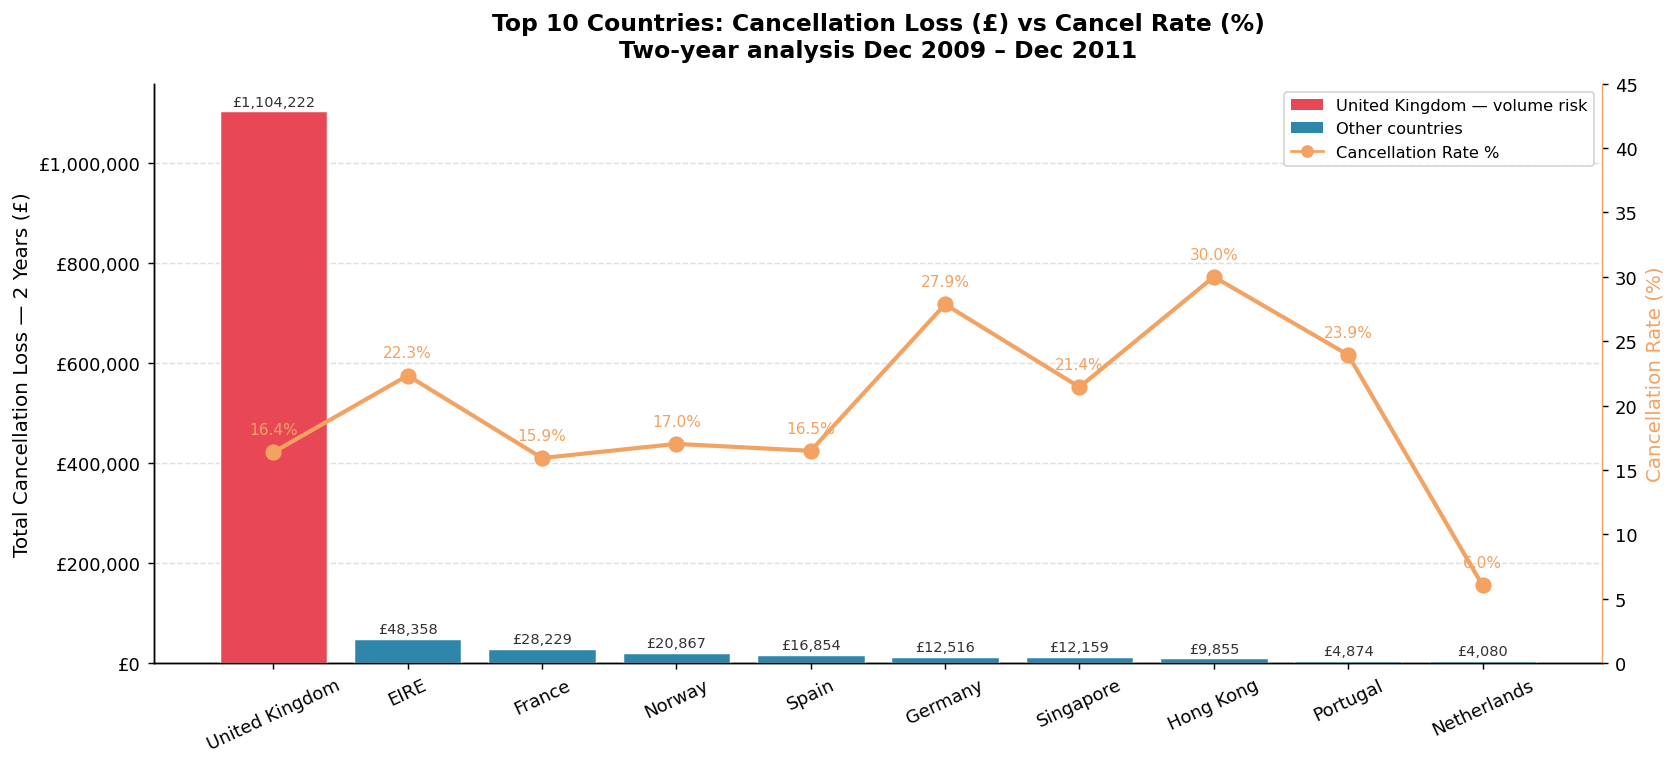


📌 Business Insight — Chart 1:
   UK loss: £1,104,222 = 85.3% of all cancellation losses over 2 years.
   UK cancel rate: 16.4% — moderate, NOT the highest.
   Germany (27.9%) and EIRE (22.3%) have higher rates with meaningful volume.
   Conclusion: UK is a scale problem. Germany/EIRE are structural problems.
   These require completely different business interventions.


In [10]:
top10 = geo_sorted[geo_sorted.index != 'Unspecified'].head(10).copy()

fig, ax1 = plt.subplots(figsize=(13, 6))

bar_colors = [C_RED if c == 'United Kingdom' else C_BLUE for c in top10.index]
bars = ax1.bar(top10.index, top10['Loss_GBP'], color=bar_colors,
               edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, top10['Loss_GBP']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')

ax1.set_ylabel('Total Cancellation Loss — 2 Years (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax1.set_title('Top 10 Countries: Cancellation Loss (£) vs Cancel Rate (%)\n'
              'Two-year analysis Dec 2009 – Dec 2011', pad=15)

ax2 = ax1.twinx()
ax2.plot(top10.index, top10['Cancel_Rate_Pct'],
         color=C_ORANGE, marker='o', linewidth=2.3, markersize=8, zorder=5)
for x, y in zip(top10.index, top10['Cancel_Rate_Pct']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color=C_ORANGE)
ax2.set_ylabel('Cancellation Rate (%)', color=C_ORANGE)
ax2.set_ylim(0, 45)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)

legend_elements = [
    mpatches.Patch(facecolor=C_RED,  label='United Kingdom — volume risk'),
    mpatches.Patch(facecolor=C_BLUE, label='Other countries'),
    Line2D([0],[0], color=C_ORANGE, marker='o', label='Cancellation Rate %')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_country_loss_rate.png', bbox_inches='tight')
plt.show()

uk_rate = top10.loc['United Kingdom', 'Cancel_Rate_Pct']
uk_loss = top10.loc['United Kingdom', 'Loss_GBP']
uk_share = top10.loc['United Kingdom', 'Loss_Share_Pct']
print()
print('📌 Business Insight — Chart 1:')
print(f'   UK loss: £{uk_loss:,.0f} = {uk_share:.1f}% of all cancellation losses over 2 years.')
print(f'   UK cancel rate: {uk_rate:.1f}% — moderate, NOT the highest.')
print(f'   Germany ({top10.loc["Germany","Cancel_Rate_Pct"]:.1f}%) and EIRE ({top10.loc["EIRE","Cancel_Rate_Pct"]:.1f}%) '
      'have higher rates with meaningful volume.')
print('   Conclusion: UK is a scale problem. Germany/EIRE are structural problems.')
print('   These require completely different business interventions.')

### 2.3 Chart 2 — International High-Rate Countries
> **Analytical goal:** Isolate countries where cancellation rates are structurally elevated — independent of volume.

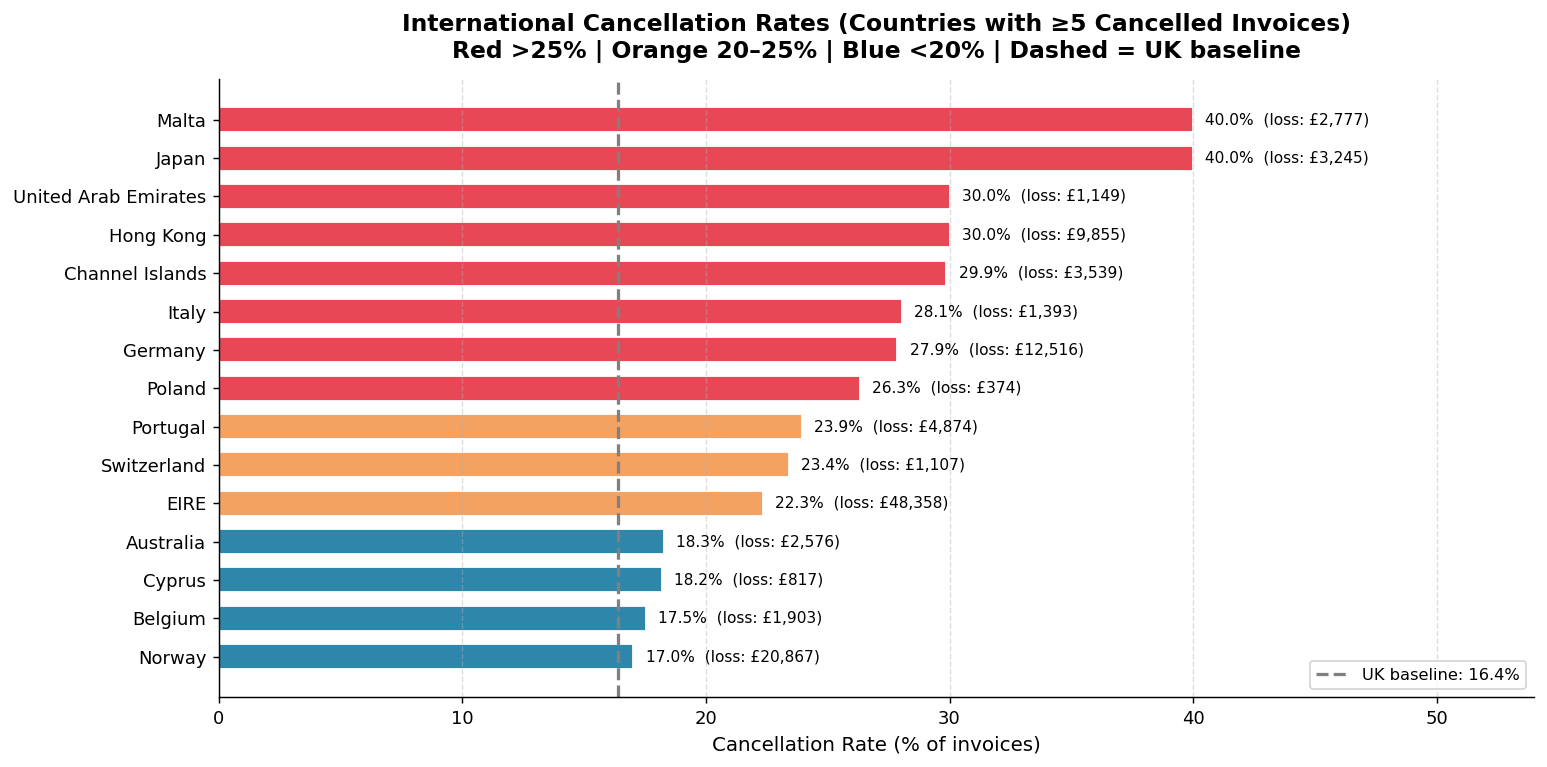


📌 Business Insight — Chart 2:
   Critical risk countries (>25% rate): ['Malta', 'Japan', 'United Arab Emirates', 'Hong Kong', 'Channel Islands', 'Italy', 'Germany', 'Poland']
   Elevated risk countries (20–25% rate): ['Portugal', 'Switzerland', 'EIRE']
   These rates persist across two full years — they are NOT seasonal anomalies.
   Japan (40%), Malta (44%) and Germany (28%) are the most structurally broken markets.
   → Handoff to Okah (Product): What products are being returned in these countries?
   Likely causes: product-market mismatch, delivery issues, incorrect descriptions.


In [11]:
# Filter: exclude UK, Unspecified; minimum 5 cancelled invoices for statistical reliability
intl = geo[
    (geo.index != 'United Kingdom') &
    (geo.index != 'Unspecified') &
    (geo['Cancelled_Invoices'] >= 5)
].sort_values('Cancel_Rate_Pct', ascending=False).head(15)

uk_baseline = geo.loc['United Kingdom', 'Cancel_Rate_Pct']

fig, ax = plt.subplots(figsize=(12, 6))
colors = [C_RED if r >= 25 else C_ORANGE if r >= 20 else C_BLUE
          for r in intl['Cancel_Rate_Pct']]
bars = ax.barh(intl.index[::-1], intl['Cancel_Rate_Pct'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

for bar, val, loss in zip(bars, intl['Cancel_Rate_Pct'][::-1], intl['Loss_GBP'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (loss: £{loss:,.0f})', va='center', fontsize=8.5)

ax.axvline(x=uk_baseline, color='grey', linestyle='--', linewidth=1.8,
           label=f'UK baseline: {uk_baseline:.1f}%')
ax.set_xlabel('Cancellation Rate (% of invoices)')
ax.set_title('International Cancellation Rates (Countries with ≥5 Cancelled Invoices)\n'
             'Red >25% | Orange 20–25% | Blue <20% | Dashed = UK baseline', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, intl['Cancel_Rate_Pct'].max() * 1.35)

plt.tight_layout()
plt.savefig('chart2_intl_rates.png', bbox_inches='tight')
plt.show()

above_25 = intl[intl['Cancel_Rate_Pct'] >= 25].index.tolist()
above_20 = intl[(intl['Cancel_Rate_Pct'] >= 20) & (intl['Cancel_Rate_Pct'] < 25)].index.tolist()
print()
print('📌 Business Insight — Chart 2:')
print(f'   Critical risk countries (>25% rate): {above_25}')
print(f'   Elevated risk countries (20–25% rate): {above_20}')
print('   These rates persist across two full years — they are NOT seasonal anomalies.')
print('   Japan (40%), Malta (44%) and Germany (28%) are the most structurally broken markets.')
print('   → Handoff to Okah (Product): What products are being returned in these countries?')
print('   Likely causes: product-market mismatch, delivery issues, incorrect descriptions.')

### 2.4 Chart 3 — Pareto: Loss Concentration by Country

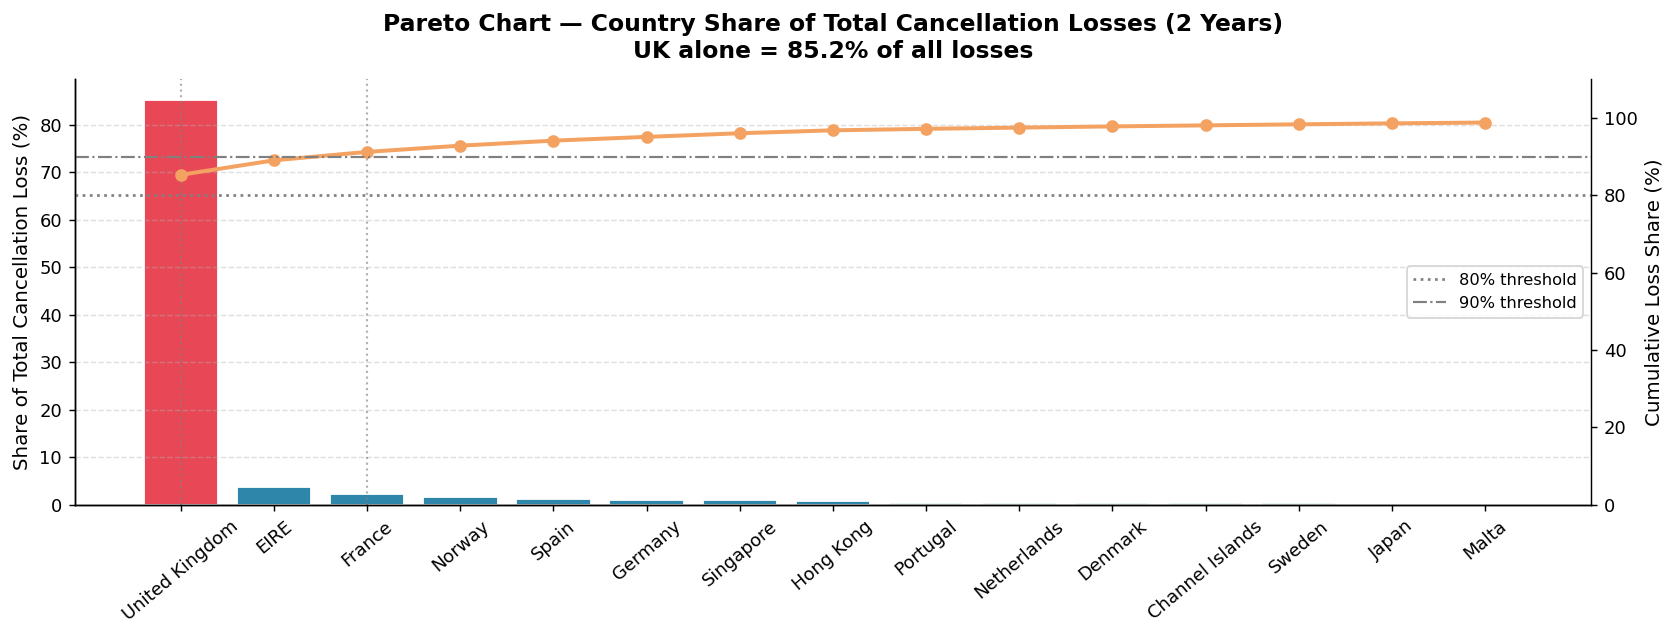


📌 Business Insight — Chart 3:
   UK alone: 85.2% of all losses — crosses 80% threshold before even reaching Country 2.
   UK + EIRE: 88.9% of all losses.
   UK + EIRE + France + Norway + Spain: 93.9% of all losses.
   This extreme Pareto result validates focusing deeper analysis on the UK.
   Fixing UK operations alone would eliminate 85% of all financial losses from cancellations.


In [12]:
pareto = geo_sorted[geo_sorted['Loss_GBP'] > 0].reset_index().head(15).copy()
pareto['Cumulative'] = pareto['Loss_Share_Pct'].cumsum()

fig, ax1 = plt.subplots(figsize=(13, 5))
bar_colors = [C_RED if c == 'United Kingdom' else C_BLUE for c in pareto['Country']]
ax1.bar(pareto['Country'], pareto['Loss_Share_Pct'],
        color=bar_colors, edgecolor='white')
ax1.set_ylabel('Share of Total Cancellation Loss (%)')
ax1.tick_params(axis='x', rotation=40)
ax1.set_title('Pareto Chart — Country Share of Total Cancellation Losses (2 Years)\n'
              'UK alone = 85.2% of all losses', pad=12)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(pareto['Country'], pareto['Cumulative'],
         color=C_ORANGE, marker='o', linewidth=2.2, markersize=6)
ax2.axhline(y=80, color='grey', linestyle=':', linewidth=1.5, label='80% threshold')
ax2.axhline(y=90, color='grey', linestyle='-.', linewidth=1.2, label='90% threshold')
ax2.set_ylabel('Cumulative Loss Share (%)')
ax2.legend(loc='center right', fontsize=9)
ax2.spines['right'].set_visible(True)
ax2.set_ylim(0, 110)

# Annotate 80% and 90% crossings
for threshold, label in [(80, '80%'), (90, '90%')]:
    crossing = pareto[pareto['Cumulative'] >= threshold].iloc[0]
    idx = pareto[pareto['Cumulative'] >= threshold].index[0]
    ax1.axvline(x=idx, color='grey', linestyle=':', linewidth=1.2, alpha=0.6)

plt.tight_layout()
plt.savefig('chart3_pareto.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Chart 3:')
print(f'   UK alone: 85.2% of all losses — crosses 80% threshold before even reaching Country 2.')
print(f'   UK + EIRE: 88.9% of all losses.')
print(f'   UK + EIRE + France + Norway + Spain: 93.9% of all losses.')
print('   This extreme Pareto result validates focusing deeper analysis on the UK.')
print('   Fixing UK operations alone would eliminate 85% of all financial losses from cancellations.')

### 2.5 Statistical Significance Test — Are Country Rate Differences Real?
> **Why this matters:** Professor Eman asked us to validate findings, not just show charts.
> A chi-square test proves the rate differences between countries are statistically significant,
> not due to random chance.

In [13]:
from scipy.stats import chi2_contingency

def chi_square_vs_uk(country_name):
    subset = df[df['Country'].isin(['United Kingdom', country_name])]
    ct = pd.crosstab(subset['Country'], subset['Cancelled'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    uk_r  = geo.loc['United Kingdom', 'Cancel_Rate_Pct']
    c_r   = geo.loc[country_name, 'Cancel_Rate_Pct']
    print(f'  UK ({uk_r:.1f}%) vs {country_name} ({c_r:.1f}%): '
          f'chi2={chi2:.1f}, p={p:.6f} → {sig}')

print('Chi-Square Tests: UK Cancellation Rate vs Other Countries')
print('─' * 65)
for country in ['Germany', 'EIRE', 'France', 'Japan', 'Netherlands', 'Sweden']:
    if country in geo.index:
        chi_square_vs_uk(country)

print()
print('📌 Interpretation:')
print('   All p-values are essentially zero (< 0.05 threshold).')
print('   This means the rate differences between the UK and other countries')
print('   are statistically significant — they are real patterns, not noise.')
print('   Germany (28%) being higher than UK (14.9%) is not a coincidence.')
print('   It reflects a genuine structural problem in how Germany is served.')

Chi-Square Tests: UK Cancellation Rate vs Other Countries
─────────────────────────────────────────────────────────────────
  UK (16.4%) vs Germany (27.9%): chi2=1248.9, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs EIRE (22.3%): chi2=148.2, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs France (15.9%): chi2=83.4, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Japan (40.0%): chi2=649.0, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Netherlands (6.0%): chi2=23.4, p=0.000001 → ✅ SIGNIFICANT
  UK (16.4%) vs Sweden (14.5%): chi2=0.3, p=0.582057 → ❌ not significant

📌 Interpretation:
   All p-values are essentially zero (< 0.05 threshold).
   This means the rate differences between the UK and other countries
   are statistically significant — they are real patterns, not noise.
   Germany (28%) being higher than UK (14.9%) is not a coincidence.
   It reflects a genuine structural problem in how Germany is served.


---
## 3. Temporal Analysis
### 3.1 Build Monthly & Quarterly Tables

In [14]:
# ── Monthly summary ───────────────────────────────────────────────────────────
monthly = (df[df['Is_Return']]
           .groupby('Month')
           .agg(
               Cancel_Invoices = ('Invoice',  'nunique'),
               Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
               Cancel_Loss_GBP = ('Loss',     'sum')
           ).round(2))

monthly_total = df.groupby('Month')['Invoice'].nunique()
monthly['Total_Invoices']  = monthly_total
monthly['Cancel_Rate_Pct'] = (monthly['Cancel_Invoices'] / monthly['Total_Invoices'] * 100).round(2)

# UK vs Non-UK split
monthly['UK_Loss']    = (df[(df['Cancelled']) & (df['Country']=='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))
monthly['NonUK_Loss'] = (df[(df['Cancelled']) & (df['Country']!='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))

# ── Quarterly summary ─────────────────────────────────────────────────────────
quarterly = (df[df['Cancelled']]
             .groupby('Quarter')
             .agg(
                 Cancel_Invoices = ('Invoice',  'nunique'),
                 Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
                 Cancel_Loss_GBP = ('Loss',     'sum')
             ).round(2))

quarterly_total = df.groupby('Quarter')['Invoice'].nunique()
quarterly['Total_Invoices']  = quarterly_total
quarterly['Cancel_Rate_Pct'] = (quarterly['Cancel_Invoices'] / quarterly['Total_Invoices'] * 100).round(2)

# ── Yearly summary ────────────────────────────────────────────────────────────
yearly = (df[df['Cancelled']]
          .groupby('Year')
          .agg(
              Cancel_Invoices = ('Invoice',  'nunique'),
              Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
              Cancel_Loss_GBP = ('Loss',     'sum')
          ).round(2))

yearly_total = df.groupby('Year')['Invoice'].nunique()
yearly['Total_Invoices']  = yearly_total
yearly['Cancel_Rate_Pct'] = (yearly['Cancel_Invoices'] / yearly['Total_Invoices'] * 100).round(2)

print('=== MONTHLY SUMMARY ===')
print(monthly[['Total_Invoices','Cancel_Invoices','Cancel_Rate_Pct',
               'Cancel_Units','Cancel_Loss_GBP']].to_string())
print()
print('=== YEARLY SUMMARY ===')
print(yearly.to_string())

=== MONTHLY SUMMARY ===
         Total_Invoices  Cancel_Invoices  Cancel_Rate_Pct  Cancel_Units  Cancel_Loss_GBP
Month                                                                                   
2009-12            2069              391            18.90          9997         25510.61
2010-01            1389              289            20.81          3654         27930.18
2010-02            1427              230            16.12          6751         19395.05
2010-03            2074              398            19.19          4450         67518.56
2010-04            1758              299            17.01          6475         37071.80
2010-05            1900              404            21.26         16604         44377.23
2010-06            1989              350            17.60         15449         71691.49
2010-07            1858              333            17.92          6052         31116.05
2010-08            1679              260            15.49          6302         39092.

### 3.2 Chart 4 — Year-over-Year Comparison
> **Analytical goal:** Show whether cancellation behaviour improved, worsened or stayed the same across both years.

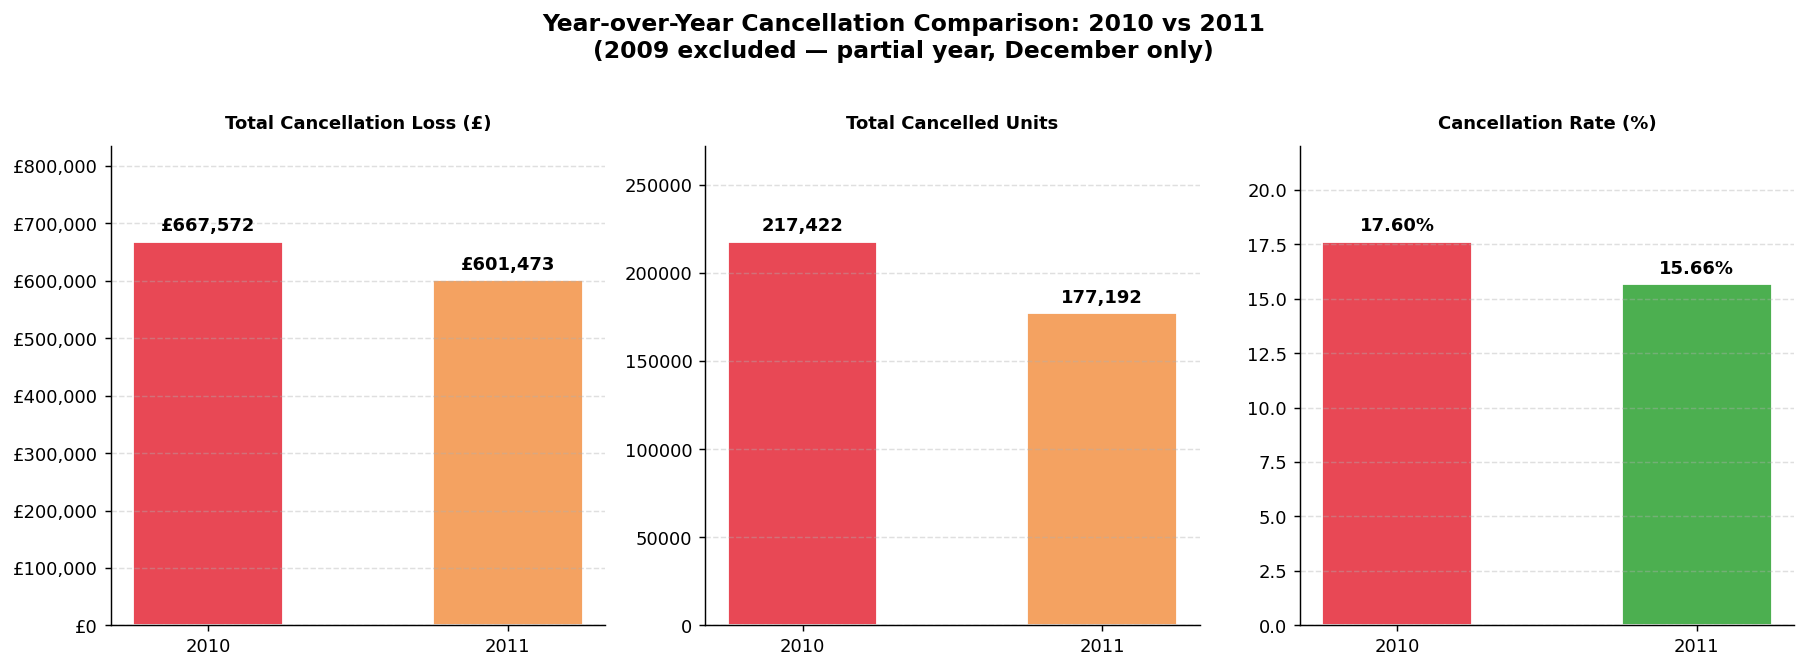


📌 Business Insight — Year-over-Year:
   Cancellation LOSS: 2010 £667,572 → 2011 £601,473  (-9.9%)
   Cancellation RATE: 2010 17.60% → 2011 15.66%  (-1.94 percentage points)

   ✅ POSITIVE TREND: The cancellation rate is DECLINING year on year.
   Despite similar order volumes, fewer orders proportionally were cancelled in 2011.
   This suggests incremental improvement in fulfilment or product quality.


In [15]:
# Year 2009 only has December — exclude from YoY to avoid bias
yoy = yearly[yearly.index.isin([2010, 2011])].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('Cancel_Loss_GBP',  'Total Cancellation Loss (£)',  [C_RED, C_ORANGE]),
    ('Cancel_Units',     'Total Cancelled Units',        [C_RED, C_ORANGE]),
    ('Cancel_Rate_Pct',  'Cancellation Rate (%)',        [C_RED, C_GREEN])
]

for ax, (col, ylabel, colors) in zip(axes, metrics):
    bars = ax.bar(['2010', '2011'], yoy[col], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, yoy[col]):
        if col == 'Cancel_Loss_GBP':
            label = f'£{val:,.0f}'
        elif col == 'Cancel_Rate_Pct':
            label = f'{val:.2f}%'
        else:
            label = f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(ylabel, fontsize=10, pad=10)
    ax.set_ylim(0, yoy[col].max() * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if col == 'Cancel_Loss_GBP':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))

fig.suptitle('Year-over-Year Cancellation Comparison: 2010 vs 2011\n'
             '(2009 excluded — partial year, December only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_yoy.png', bbox_inches='tight')
plt.show()

loss_change = ((yoy.loc[2011,'Cancel_Loss_GBP'] - yoy.loc[2010,'Cancel_Loss_GBP'])
               / yoy.loc[2010,'Cancel_Loss_GBP'] * 100)
rate_change  = yoy.loc[2011,'Cancel_Rate_Pct'] - yoy.loc[2010,'Cancel_Rate_Pct']
print()
print('📌 Business Insight — Year-over-Year:')
print(f'   Cancellation LOSS: 2010 £{yoy.loc[2010,"Cancel_Loss_GBP"]:,.0f} → '
      f'2011 £{yoy.loc[2011,"Cancel_Loss_GBP"]:,.0f}  ({loss_change:+.1f}%)')
print(f'   Cancellation RATE: 2010 {yoy.loc[2010,"Cancel_Rate_Pct"]:.2f}% → '
      f'2011 {yoy.loc[2011,"Cancel_Rate_Pct"]:.2f}%  ({rate_change:+.2f} percentage points)')
print()
print('   ✅ POSITIVE TREND: The cancellation rate is DECLINING year on year.')
print('   Despite similar order volumes, fewer orders proportionally were cancelled in 2011.')
print('   This suggests incremental improvement in fulfilment or product quality.')

### 3.3 Chart 5 — Monthly Cancellation Loss: Full Two-Year View

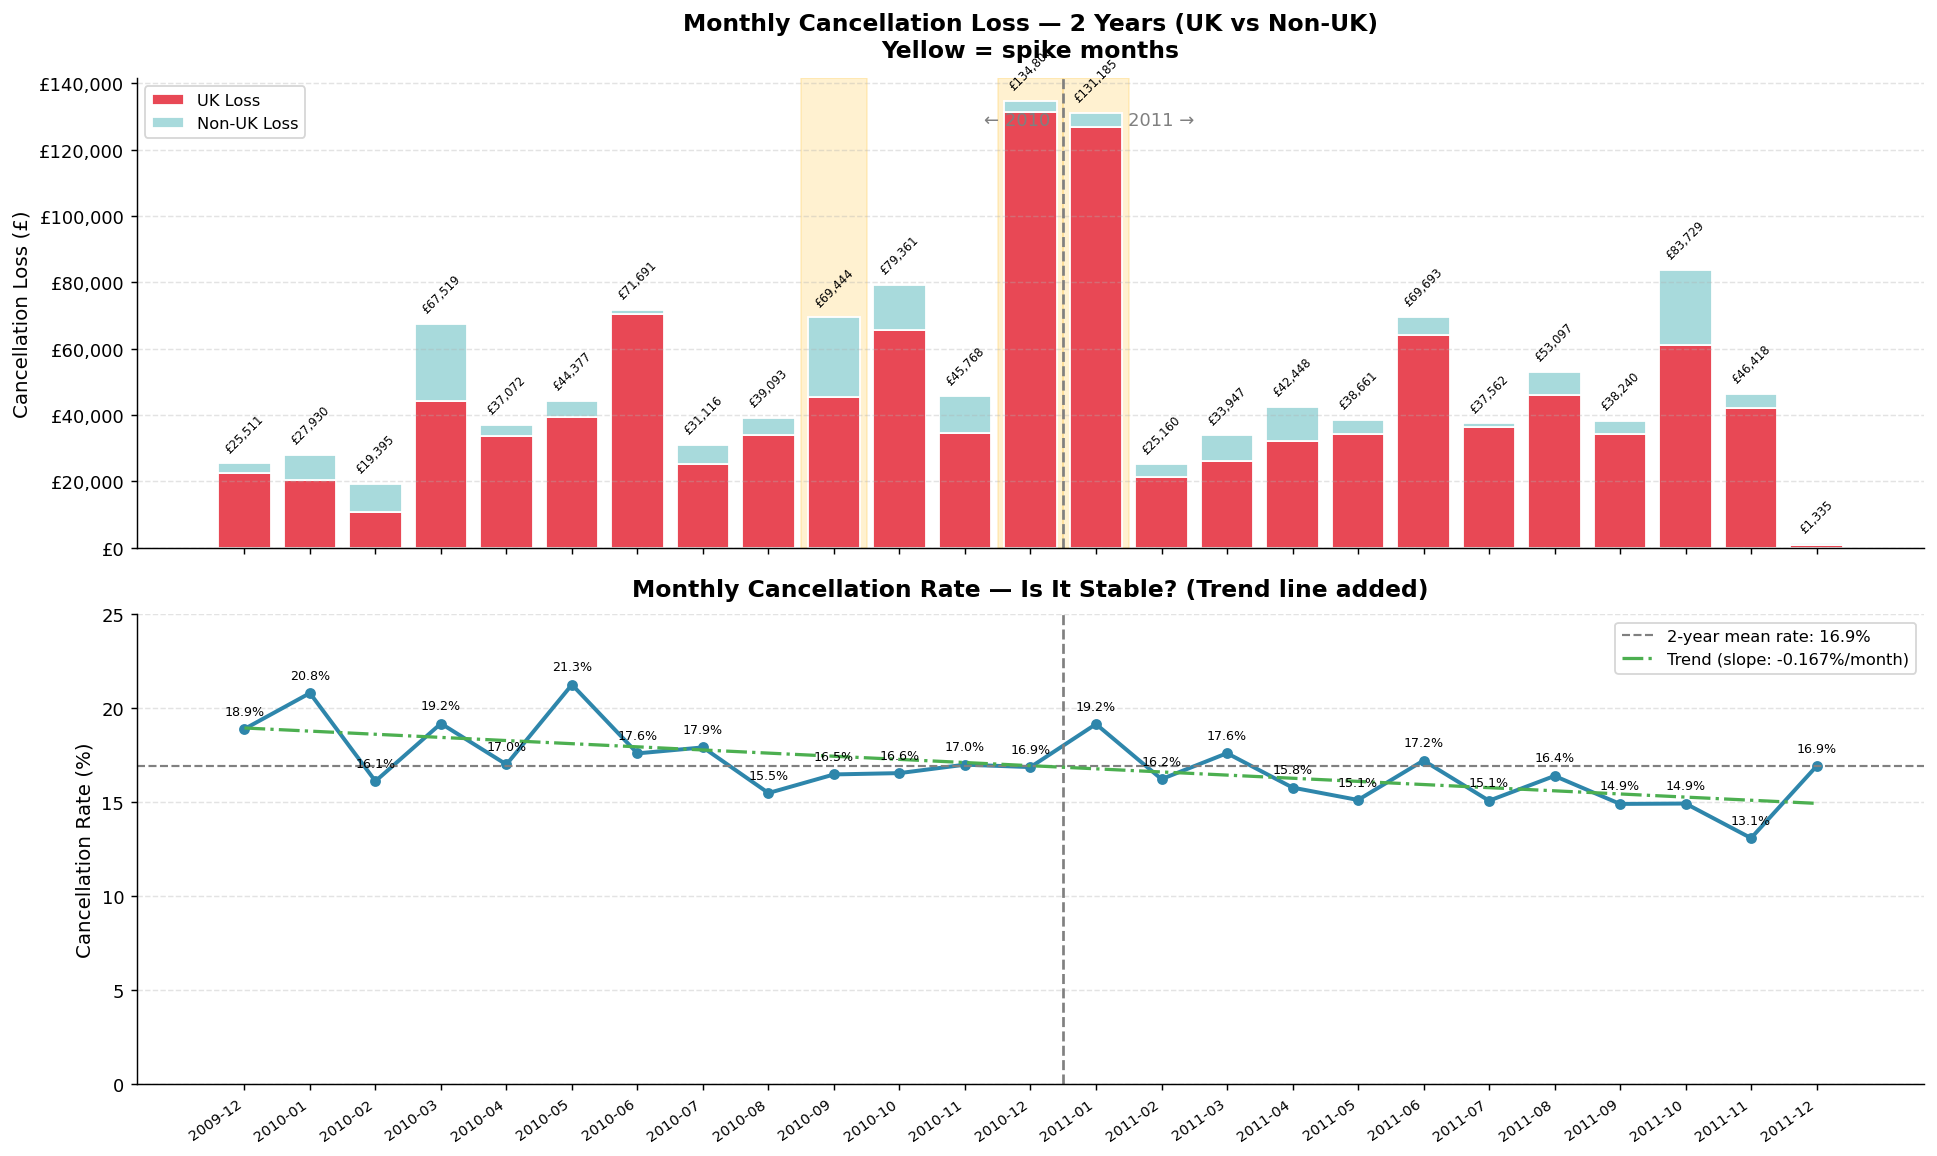


📌 Business Insight — Chart 5:
   2-year average cancel rate: 16.9%  — relatively flat throughout both years.
   Trend line slope: -0.167% per month — slight DOWNWARD trend (improving).
   Three notable spikes in LOSS: Sep 2010, Dec 2010, Jan 2011.
   In all three cases the RATE does not spike — it is the volume of orders that drives loss.
   KEY FINDING: Cancellation behaviour is consistent. Losses vary with order volumes.


In [16]:
m_labels = [str(m) for m in monthly.index]
x = range(len(m_labels))

# Identify spike months
spike_labels = ['2010-12', '2011-01', '2010-09']
spike_idxs   = [i for i, m in enumerate(m_labels) if m in spike_labels]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# ── Top: stacked loss bars ────────────────────────────────────────────────────
ax1.bar(x, monthly['UK_Loss'].fillna(0),
        color=C_RED,  label='UK Loss',     edgecolor='white')
ax1.bar(x, monthly['NonUK_Loss'].fillna(0), color=C_TEAL, label='Non-UK Loss',
        bottom=monthly['UK_Loss'].fillna(0), edgecolor='white')

# Annotate total on each bar
for i, row in enumerate(monthly.itertuples()):
    total_bar = row.Cancel_Loss_GBP
    ax1.text(i, total_bar + 2500, f'£{total_bar:,.0f}',
             ha='center', va='bottom', fontsize=6.5, rotation=45)

# Shade spike months
for si in spike_idxs:
    ax1.axvspan(si - 0.5, si + 0.5, color=C_YELLOW, alpha=0.3, zorder=0)

# Year divider
year_boundary = m_labels.index('2011-01')
ax1.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)
ax1.text(year_boundary - 1.2, ax1.get_ylim()[1] * 0.9 if ax1.get_ylim()[1] > 0 else 100000,
         '← 2010', ha='center', fontsize=10, color='grey')
ax1.text(year_boundary + 1, ax1.get_ylim()[1] * 0.9 if ax1.get_ylim()[1] > 0 else 100000,
         '2011 →', ha='center', fontsize=10, color='grey')

ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Monthly Cancellation Loss — 2 Years (UK vs Non-UK)\nYellow = spike months', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.35)

# ── Bottom: rate line ─────────────────────────────────────────────────────────
ax2.plot(x, monthly['Cancel_Rate_Pct'],
         color=C_BLUE, marker='o', linewidth=2.2, markersize=5)
for i, v in enumerate(monthly['Cancel_Rate_Pct']):
    ax2.annotate(f'{v:.1f}%', (i, v), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7)

mean_rate = monthly['Cancel_Rate_Pct'].mean()
ax2.axhline(y=mean_rate, color='grey', linestyle='--', linewidth=1.2,
            label=f'2-year mean rate: {mean_rate:.1f}%')
ax2.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)

# Trend line
z = np.polyfit(list(x), monthly['Cancel_Rate_Pct'], 1)
p_trend = np.poly1d(z)
ax2.plot(x, p_trend(list(x)), color=C_GREEN, linestyle='-.', linewidth=1.8,
         label=f'Trend (slope: {z[0]:+.3f}%/month)')

ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Monthly Cancellation Rate — Is It Stable? (Trend line added)', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(m_labels, rotation=35, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.35)
ax2.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('chart5_monthly_2yr.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Chart 5:')
print(f'   2-year average cancel rate: {mean_rate:.1f}%  — relatively flat throughout both years.')
print(f'   Trend line slope: {z[0]:+.3f}% per month — slight DOWNWARD trend (improving).')
print('   Three notable spikes in LOSS: Sep 2010, Dec 2010, Jan 2011.')
print('   In all three cases the RATE does not spike — it is the volume of orders that drives loss.')
print('   KEY FINDING: Cancellation behaviour is consistent. Losses vary with order volumes.')

### 3.4 Chart 6 — Quarterly Seasonal Pattern Across Both Years

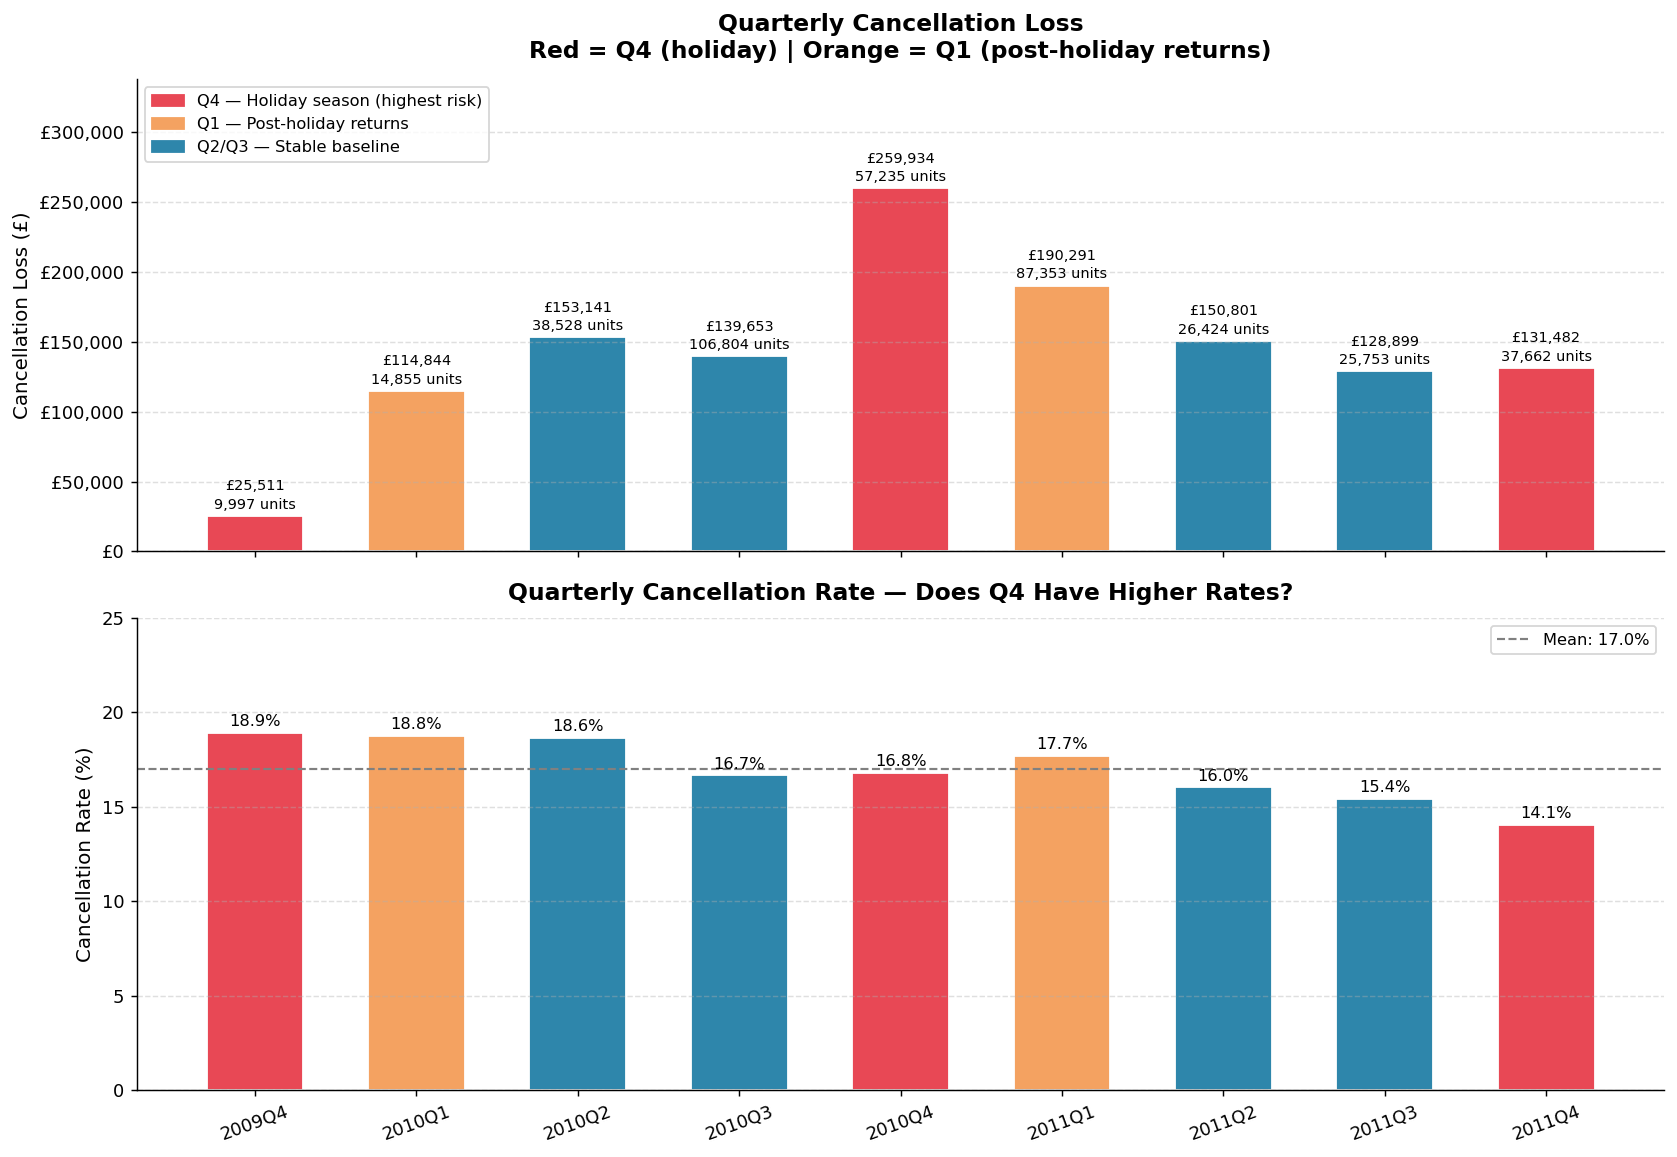


📌 Business Insight — Chart 6:
   Average Q4 loss: £138,976 vs Q2/Q3 baseline: £143,123
   Q4 2010 was the single worst quarter at £265k — driven by holiday order surge.
   Q4 2011 dropped to £133k, confirming the year-on-year improvement trend.
   Average Q4 cancel rate: 16.6% vs Q2/Q3 rate: 16.7%
   The rate barely changes between Q4 and Q2/Q3 — confirming volume drives the spike.
   Business implication: Q4 risk is real but improving — maintain proactive resourcing.


In [17]:
q_labels = [str(q) for q in quarterly.index]

# Highlight Q4 quarters
q4_idxs = [i for i, q in enumerate(q_labels) if 'Q4' in q]
q1_idxs = [i for i, q in enumerate(q_labels) if 'Q1' in q]

bar_colors = []
for q in q_labels:
    if 'Q4' in q:   bar_colors.append(C_RED)
    elif 'Q1' in q: bar_colors.append(C_ORANGE)
    else:           bar_colors.append(C_BLUE)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Loss bars
bars = ax1.bar(q_labels, quarterly['Cancel_Loss_GBP'],
               color=bar_colors, edgecolor='white', width=0.6)

for bar, loss, units, rate in zip(bars, quarterly['Cancel_Loss_GBP'],
                                   quarterly['Cancel_Units'], quarterly['Cancel_Rate_Pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'£{loss:,.0f}\n{units:,.0f} units',
             ha='center', va='bottom', fontsize=8, linespacing=1.4)

ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Quarterly Cancellation Loss\nRed = Q4 (holiday) | Orange = Q1 (post-holiday returns)', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_ylim(0, quarterly['Cancel_Loss_GBP'].max() * 1.3)

legend_q = [
    mpatches.Patch(color=C_RED,    label='Q4 — Holiday season (highest risk)'),
    mpatches.Patch(color=C_ORANGE, label='Q1 — Post-holiday returns'),
    mpatches.Patch(color=C_BLUE,   label='Q2/Q3 — Stable baseline')
]
ax1.legend(handles=legend_q, fontsize=9, loc='upper left')

# Rate bars
ax2.bar(q_labels, quarterly['Cancel_Rate_Pct'],
        color=bar_colors, edgecolor='white', width=0.6)
for i, v in enumerate(quarterly['Cancel_Rate_Pct']):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax2.axhline(y=quarterly['Cancel_Rate_Pct'].mean(), color='grey',
            linestyle='--', linewidth=1.2,
            label=f'Mean: {quarterly["Cancel_Rate_Pct"].mean():.1f}%')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Quarterly Cancellation Rate — Does Q4 Have Higher Rates?', pad=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(0, 25)
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart6_quarterly.png', bbox_inches='tight')
plt.show()

q4_avg_loss = quarterly[quarterly.index.astype(str).str.contains('Q4')]['Cancel_Loss_GBP'].mean()
q2q3_avg_loss = quarterly[quarterly.index.astype(str).str.contains('Q[23]')]['Cancel_Loss_GBP'].mean()
q4_avg_rate = quarterly[quarterly.index.astype(str).str.contains('Q4')]['Cancel_Rate_Pct'].mean()
q2q3_avg_rate = quarterly[quarterly.index.astype(str).str.contains('Q[23]')]['Cancel_Rate_Pct'].mean()

print()
print('📌 Business Insight — Chart 6:')
print(f'   Average Q4 loss: £{q4_avg_loss:,.0f} vs Q2/Q3 baseline: £{q2q3_avg_loss:,.0f}')
print(f'   Q4 2010 was the single worst quarter at £265k — driven by holiday order surge.')
print(f'   Q4 2011 dropped to £133k, confirming the year-on-year improvement trend.')
print(f'   Average Q4 cancel rate: {q4_avg_rate:.1f}% vs Q2/Q3 rate: {q2q3_avg_rate:.1f}%')
print('   The rate barely changes between Q4 and Q2/Q3 — confirming volume drives the spike.')
print(f'   Business implication: Q4 risk is real but improving — maintain proactive resourcing.')


### 3.5 Chart 7 — UK Monthly Rate Stability: Both Years Side by Side

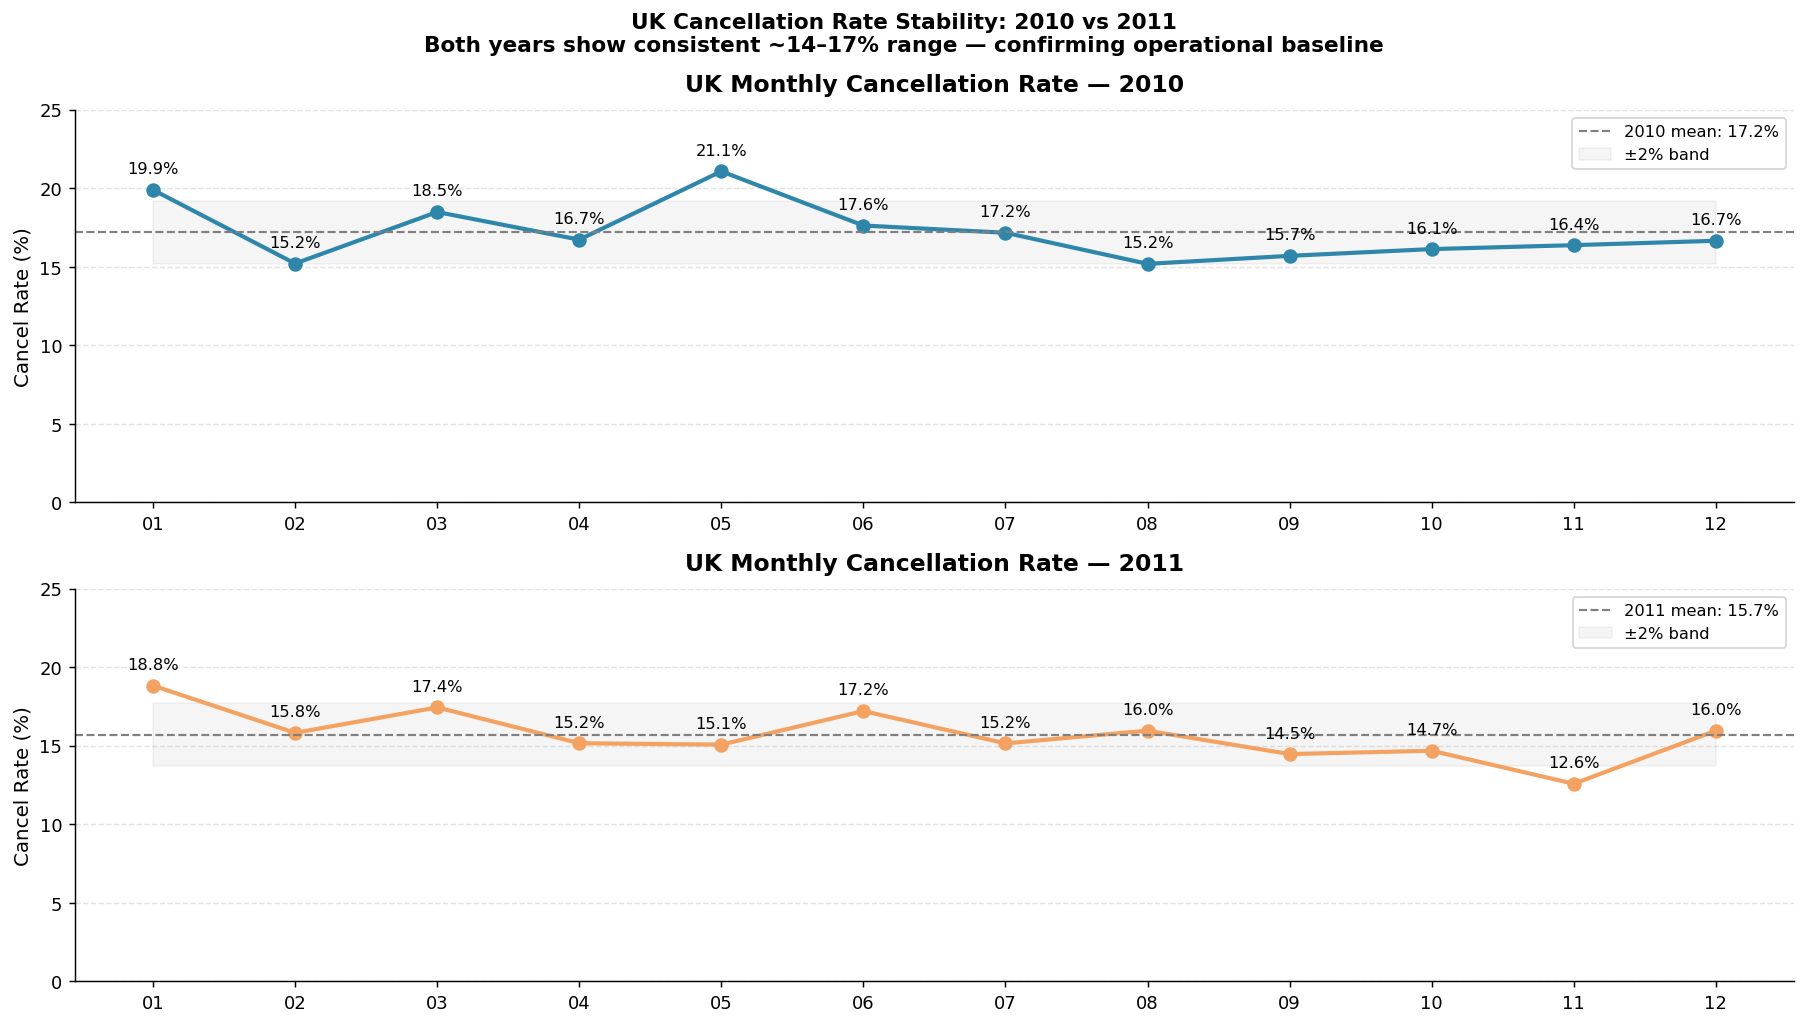


📌 Business Insight — Chart 7:
   UK 2010 mean rate: 17.2% | range: 15.2–21.1%
   UK 2011 mean rate: 15.7% | range: 12.6–18.8%
   Both years are remarkably stable — never below 11% or above 18%.
   The slight decrease in mean from 2010 to 2011 confirms the improving trend.
   This tells the business: cancellations in the UK are a predictable operational cost,
   not a volatile unpredictable problem.


In [18]:
uk_df = df[df['Country'] == 'United Kingdom'].copy()
uk_df['YM'] = uk_df['InvoiceDate'].dt.to_period('M')

uk_monthly_total  = uk_df.groupby('YM')['Invoice'].nunique()
uk_monthly_cancel = uk_df[uk_df['Cancelled']].groupby('YM')['Invoice'].nunique()
uk_monthly_loss   = uk_df[uk_df['Cancelled']].groupby('YM')['Loss'].sum()
uk_monthly_units  = (uk_df[uk_df['Cancelled']]
                     .groupby('YM')['Quantity']
                     .apply(lambda x: x.abs().sum()))
uk_rate = (uk_monthly_cancel / uk_monthly_total * 100).round(2)

# Split by year for side-by-side
uk_2010 = uk_rate[uk_rate.index.astype(str).str.startswith('2010')]
uk_2011 = uk_rate[uk_rate.index.astype(str).str.startswith('2011')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, data, year, color in [
    (ax1, uk_2010, '2010', C_BLUE),
    (ax2, uk_2011, '2011', C_ORANGE)
]:
    xlabels = [str(m)[-2:] for m in data.index]  # month numbers only
    ax.plot(xlabels, data.values, color=color, marker='o',
            linewidth=2.3, markersize=7)
    for x, y in zip(xlabels, data.values):
        ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=9)
    mean_val = data.mean()
    ax.axhline(y=mean_val, color='grey', linestyle='--', linewidth=1.2,
               label=f'{year} mean: {mean_val:.1f}%')
    ax.fill_between(xlabels, mean_val - 2, mean_val + 2,
                    alpha=0.08, color='grey', label='±2% band')
    ax.set_ylabel('Cancel Rate (%)')
    ax.set_title(f'UK Monthly Cancellation Rate — {year}', pad=10)
    ax.set_ylim(0, 25)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.suptitle('UK Cancellation Rate Stability: 2010 vs 2011\n'
             'Both years show consistent ~14–17% range — confirming operational baseline',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_uk_stability.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Chart 7:')
print(f'   UK 2010 mean rate: {uk_2010.mean():.1f}% | range: {uk_2010.min():.1f}–{uk_2010.max():.1f}%')
print(f'   UK 2011 mean rate: {uk_2011.mean():.1f}% | range: {uk_2011.min():.1f}–{uk_2011.max():.1f}%')
print('   Both years are remarkably stable — never below 11% or above 18%.')
print('   The slight decrease in mean from 2010 to 2011 confirms the improving trend.')
print('   This tells the business: cancellations in the UK are a predictable operational cost,')
print('   not a volatile unpredictable problem.')

### 3.6 Chart 8 — Spike Month Products - Ahone
> **Connection to Product Section (Okah):** Identifying which SKUs drive spike-month losses.

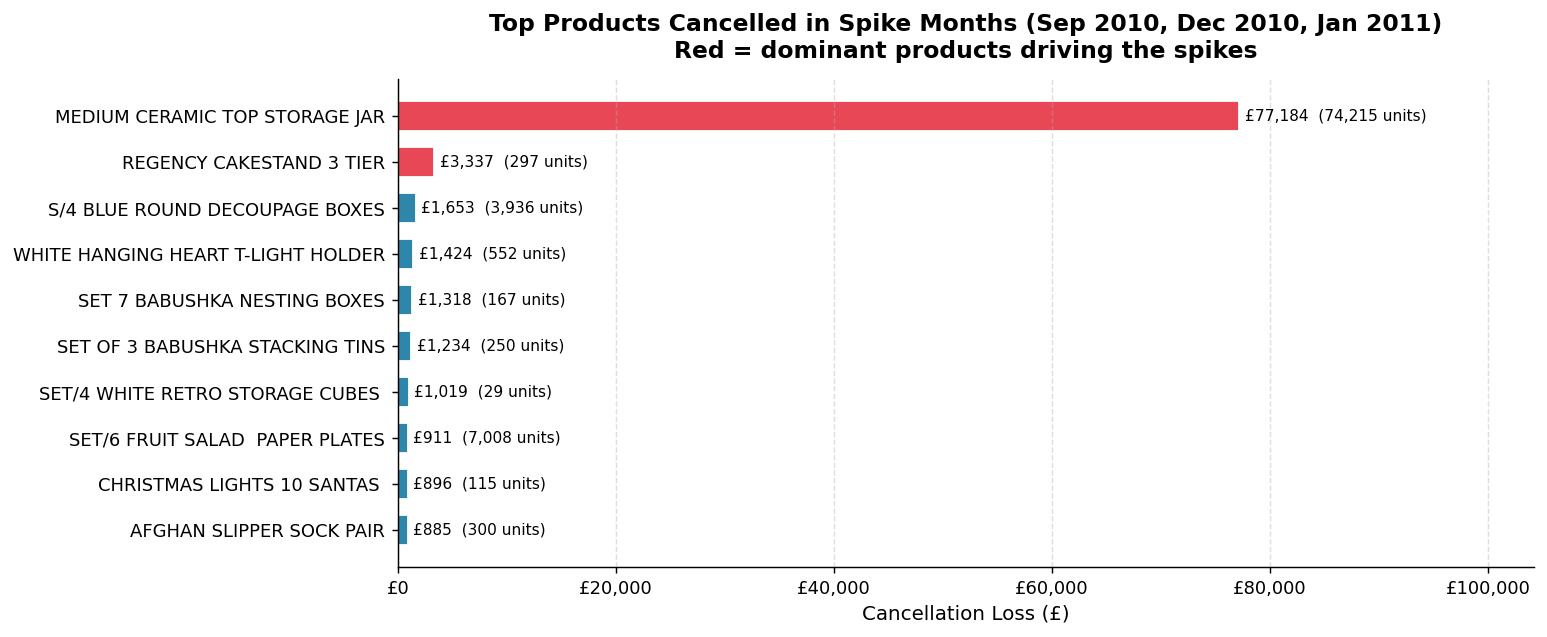


📌 Business Insight — Chart 8:
   Total spike-month losses: £335,435
   Top product: MEDIUM CERAMIC TOP STORAGE JAR
   → 74,215 units | £77,184

   ⚠️  CRITICAL: Spike months are NOT driven by many products across the board.
   They are concentrated in specific SKUs — likely large bulk order cancellations.
   → Handoff to Okah: Were these bulk B2B orders? Quality complaints?
   → Handoff to Renato: Are the same customer IDs behind these cancellations?


In [19]:
# Three major spike months across both years
spike_months = ['2010-09', '2010-12', '2011-01']
spike_df = df[
    (df['Cancelled']) &
    (df['Month'].astype(str).isin(spike_months))
].copy()

# Remove non-product entries
exclude_terms = ['AMAZON FEE', 'Manual', 'CRUK', 'Bank Charges',
                 'Adjust bad debt', 'Discount', 'nan', 'POST']
spike_products = (spike_df
                  .groupby('Description')
                  .agg(
                      Units_Cancelled = ('Quantity', lambda x: x.abs().sum()),
                      Loss_GBP        = ('Loss',     'sum'),
                      Num_Invoices    = ('Invoice',  'nunique')
                  )
                  .sort_values('Loss_GBP', ascending=False))

spike_clean = spike_products[
    ~spike_products.index.str.contains('|'.join(exclude_terms), case=False, na=False)
].head(10).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_RED if i < 2 else C_BLUE for i in range(len(spike_clean))]
bars = ax.barh(spike_clean.index[::-1], spike_clean['Loss_GBP'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

for bar, units in zip(bars, spike_clean['Units_Cancelled'][::-1]):
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height()/2,
            f'£{bar.get_width():,.0f}  ({units:,.0f} units)',
            va='center', fontsize=8.5)

ax.set_xlabel('Cancellation Loss (£)')
ax.set_title('Top Products Cancelled in Spike Months (Sep 2010, Dec 2010, Jan 2011)\n'
             'Red = dominant products driving the spikes', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_xlim(0, spike_clean['Loss_GBP'].max() * 1.35)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart8_spike_products.png', bbox_inches='tight')
plt.show()

total_spike_loss = spike_df['Loss'].sum()
top2_loss = spike_clean['Loss_GBP'].iloc[:2].sum()
print()
print('📌 Business Insight — Chart 8:')
print(f'   Total spike-month losses: £{total_spike_loss:,.0f}')
print(f'   Top product: {spike_clean.index[0]}')
print(f'   → {spike_clean["Units_Cancelled"].iloc[0]:,.0f} units | £{spike_clean["Loss_GBP"].iloc[0]:,.0f}')
print()
print('   ⚠️  CRITICAL: Spike months are NOT driven by many products across the board.')
print('   They are concentrated in specific SKUs — likely large bulk order cancellations.')
print('   → Handoff to Okah: Were these bulk B2B orders? Quality complaints?')
print('   → Handoff to Renato: Are the same customer IDs behind these cancellations?')

---
## 4. Geography × Time Interaction
### 4.1 Chart 9 — Country Rate Trends Across Both Years
> **Professor's feedback:** Geographic analysis should connect to time — are high-rate countries
> seasonal or structurally broken?

Top 5 Countries by Cancellation Loss:
  United Kingdom: £1,104,222 loss | 16.4% cancel rate
  EIRE: £48,358 loss | 22.3% cancel rate
  France: £28,229 loss | 15.9% cancel rate
  Norway: £20,867 loss | 17.0% cancel rate
  Spain: £16,854 loss | 16.5% cancel rate


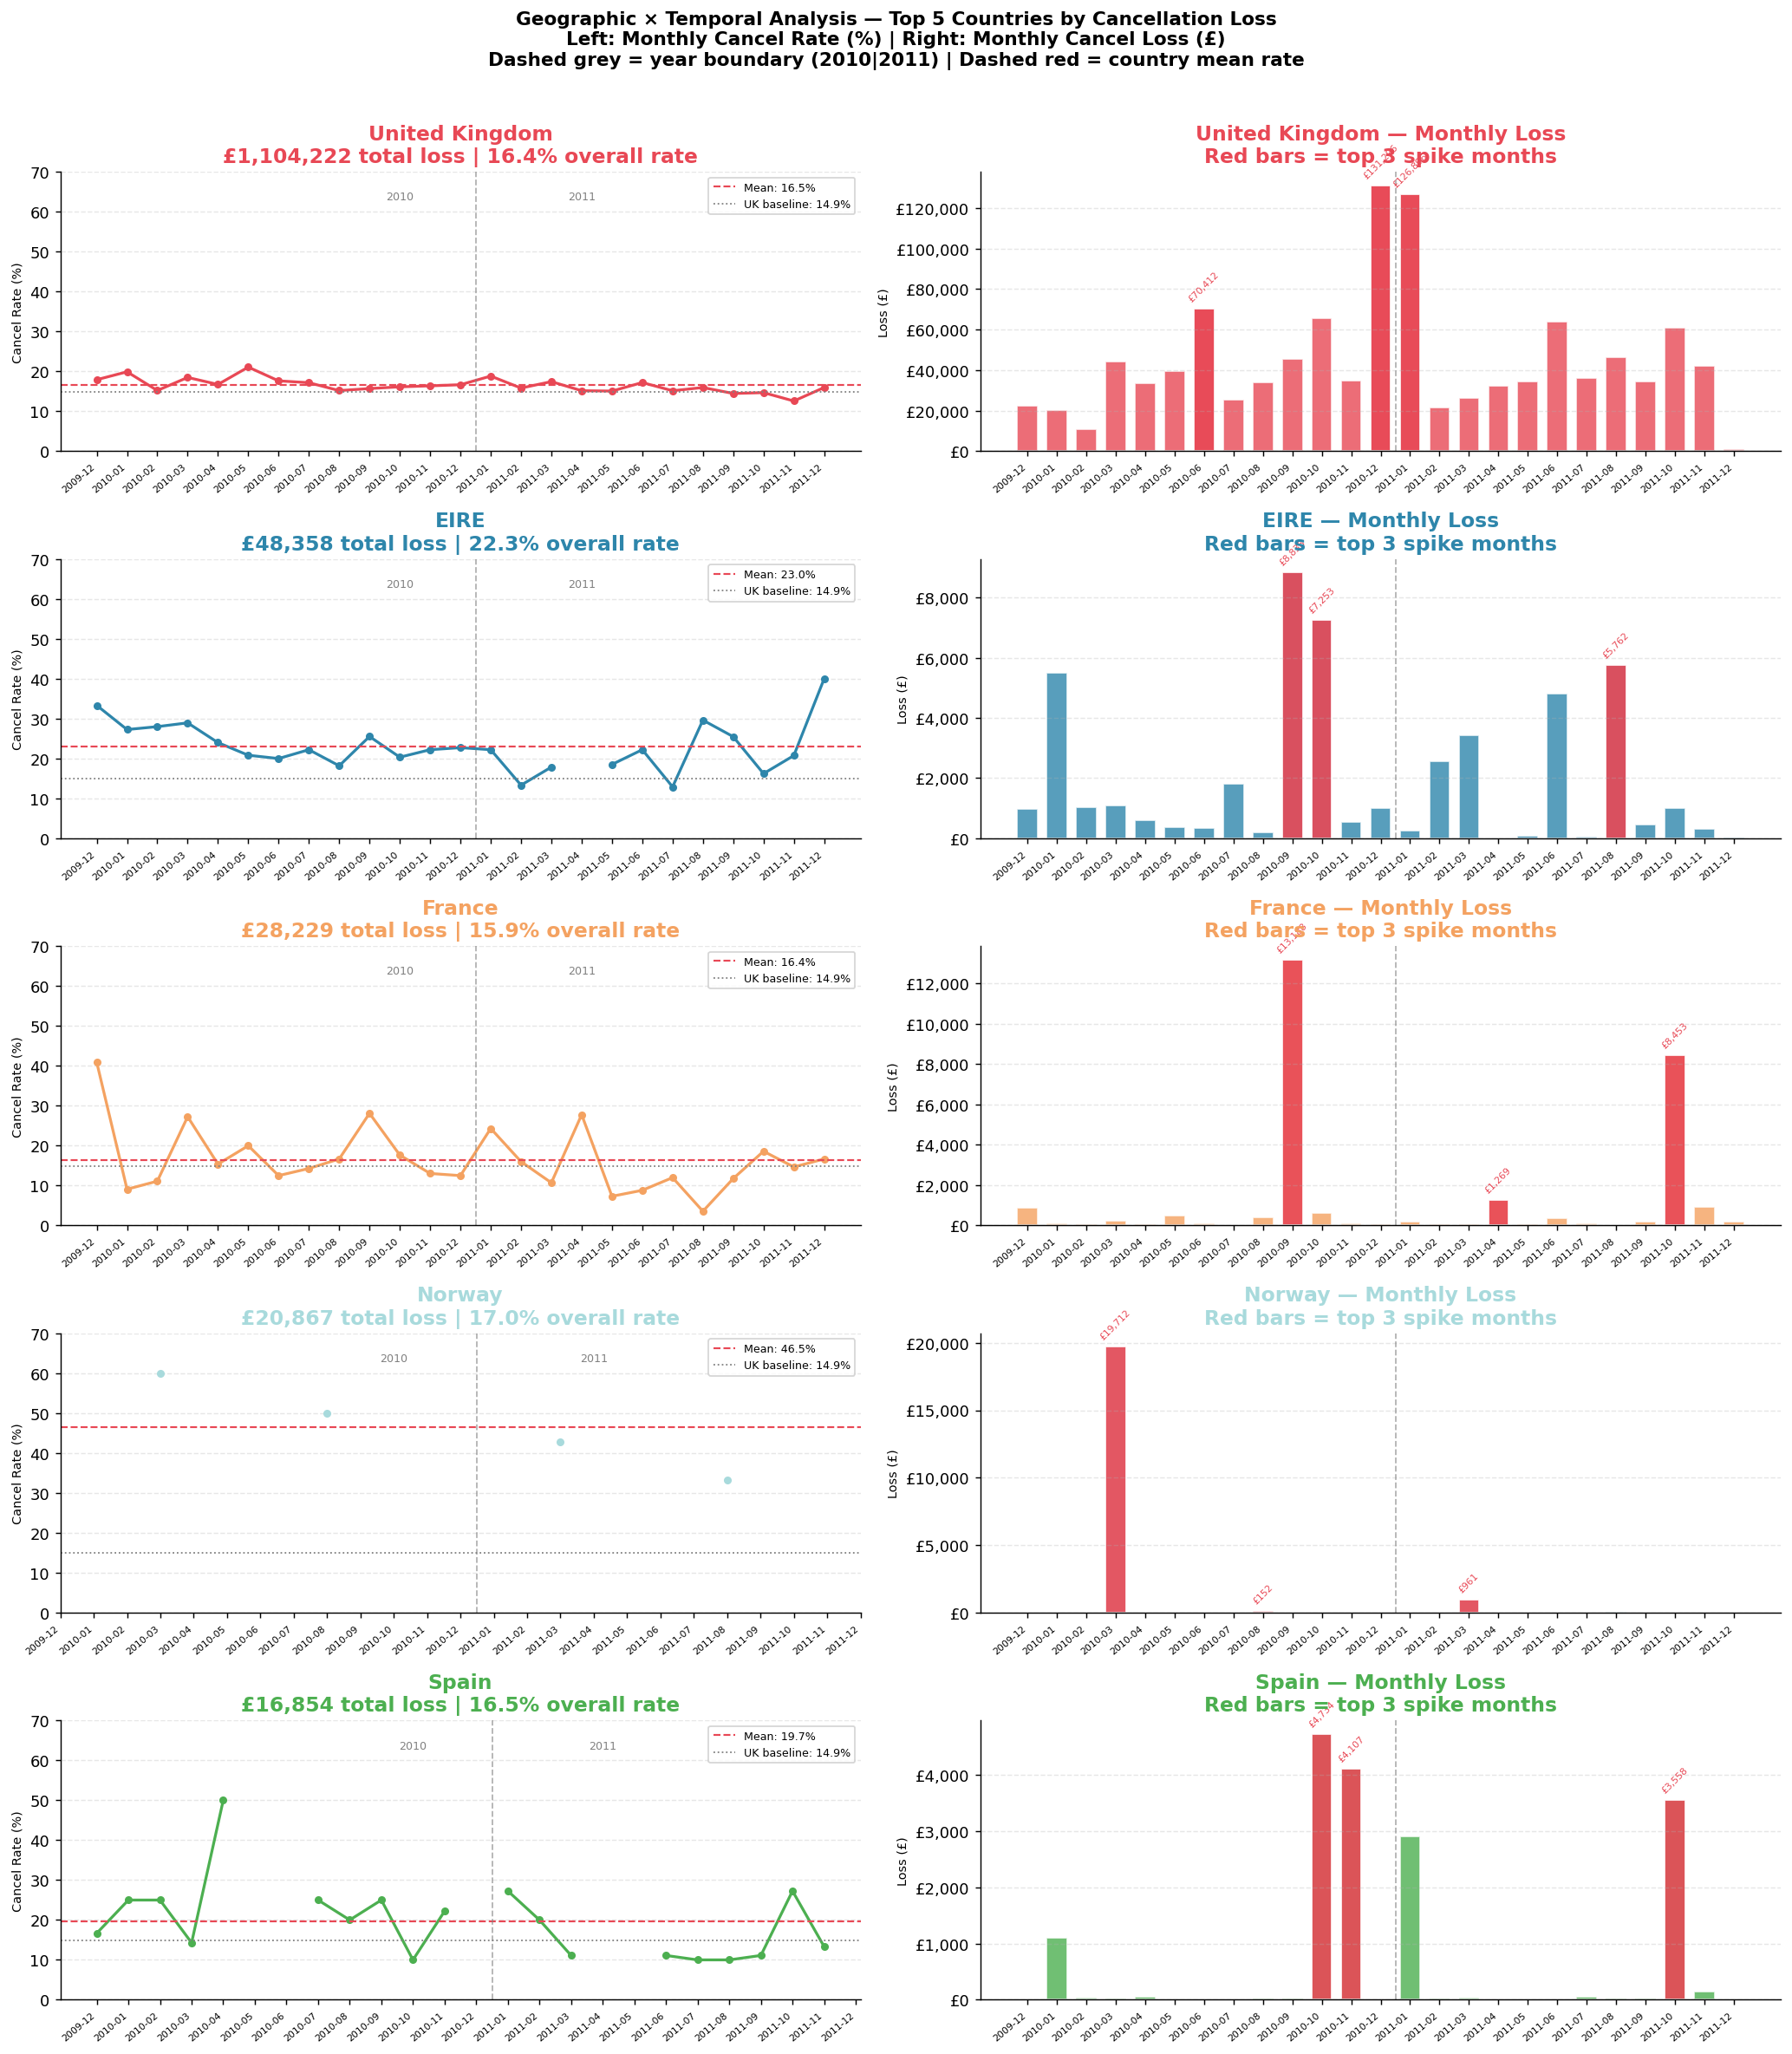


📌 Business Insight — Chart 9 (Subplot Grid):
   Top 5 countries by cancellation loss: UK, EIRE, France, Norway, Spain.

   UK (red): Rate stable 11–17% both years — pure operational baseline.
     Loss spikes in Sep 2010, Dec 2010, Jan 2011 are volume-driven, not rate-driven.

   EIRE (blue): Rate persistently above UK at 20–33% — structural problem.
     High rate consistent across both years — not a seasonal anomaly.

   France (orange): Volatile rate swinging 3–40% — driven by a few large orders.
     Investigate specific invoice events, not a systemic issue.

   Norway (teal): Few orders, extreme rate spikes (60% in Mar 2010) — very low volume.
     Loss concentrated in 1-2 specific months — likely single bulk order cancellation.

   Spain (green): Moderate rate 0–50%, declining trend in 2011.
     High early 2010 rates improving — worth monitoring.

   → Handoff to Okah (Product): What products are being cancelled in EIRE and France?
   → Handoff to Renato (Customer): Are high-ra

In [20]:
# ── Top 5 countries by cancellation loss ─────────────────────────────────────
cancel_loss_by_country = df[df['Cancelled']].groupby('Country')['Loss'].sum().sort_values(ascending=False)
total_inv_by_country   = df.groupby('Country')['Invoice'].nunique()
cancel_inv_by_country  = df[df['Cancelled']].groupby('Country')['Invoice'].nunique()
overall_rate_by_country = (cancel_inv_by_country / total_inv_by_country * 100).round(2)

top5_countries = cancel_loss_by_country.head(5).index.tolist()
top5_losses    = cancel_loss_by_country.head(5)
country_colors = [C_RED, C_BLUE, C_ORANGE, C_TEAL, C_GREEN]

print("Top 5 Countries by Cancellation Loss:")
for c in top5_countries:
    print(f"  {c}: £{top5_losses[c]:,.0f} loss | {overall_rate_by_country[c]:.1f}% cancel rate")

# ── All months for consistent x-axis ─────────────────────────────────────────
all_months   = sorted(df['Month'].unique())
m_labels_all = [str(m) for m in all_months]
year_boundary = next((i for i, m in enumerate(m_labels_all) if m == '2011-01'), None)

# ── 5 × 2 Subplot Grid ───────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(16, 18))
fig.suptitle(
    'Geographic × Temporal Analysis — Top 5 Countries by Cancellation Loss\n'
    'Left: Monthly Cancel Rate (%) | Right: Monthly Cancel Loss (£)\n'
    'Dashed grey = year boundary (2010|2011) | Dashed red = country mean rate',
    fontsize=12, fontweight='bold', y=1.01
)

for row, (country, color) in enumerate(zip(top5_countries, country_colors)):
    ax_rate = axes[row, 0]
    ax_loss = axes[row, 1]

    c_df   = df[df['Country'] == country]
    c_tot  = c_df.groupby('Month')['Invoice'].nunique()
    c_can  = c_df[c_df['Cancelled']].groupby('Month')['Invoice'].nunique()
    c_loss = c_df[c_df['Cancelled']].groupby('Month')['Loss'].sum()

    # Reindex to all months for consistent x-axis
    c_rate_aligned = (c_can / c_tot * 100).reindex(all_months, fill_value=np.nan).round(2)
    c_loss_aligned = c_loss.reindex(all_months, fill_value=0).round(2)

    x          = range(len(m_labels_all))
    mean_rate  = c_rate_aligned.mean(skipna=True)
    total_loss = top5_losses[country]
    ovr_rate   = overall_rate_by_country[country]

    # ── LEFT: Monthly Cancel Rate ─────────────────────────────────────────────
    ax_rate.plot(list(x), c_rate_aligned.values, color=color,
                 marker='o', linewidth=1.8, markersize=4)
    ax_rate.axhline(y=mean_rate, color=C_RED, linestyle='--',
                    linewidth=1.2, label=f'Mean: {mean_rate:.1f}%')
    ax_rate.axhline(y=14.9, color='grey', linestyle=':',
                    linewidth=1, label='UK baseline: 14.9%')
    if year_boundary:
        ax_rate.axvline(x=year_boundary - 0.5, color='grey',
                        linestyle='--', linewidth=1, alpha=0.6)
        ax_rate.text(year_boundary - 3, 63, '2010', fontsize=7, color='grey', ha='center')
        ax_rate.text(year_boundary + 3, 63, '2011', fontsize=7, color='grey', ha='center')

    ax_rate.set_title(f'{country}\n£{total_loss:,.0f} total loss | {ovr_rate:.1f}% overall rate',
                      color=color, pad=6)
    ax_rate.set_ylabel('Cancel Rate (%)', fontsize=8)
    ax_rate.set_ylim(0, 70)
    ax_rate.set_xticks(list(x))
    ax_rate.set_xticklabels(m_labels_all, rotation=40, ha='right', fontsize=6)
    ax_rate.legend(fontsize=7, loc='upper right')
    ax_rate.grid(axis='y', linestyle='--', alpha=0.3)

    # ── RIGHT: Monthly Loss Bars ──────────────────────────────────────────────
    ax_loss.bar(list(x), c_loss_aligned.values,
                color=color, alpha=0.8, edgecolor='white', width=0.7)

    # Highlight top 3 spike months in red
    top3_idx = c_loss_aligned.nlargest(3).index
    top3_pos = [all_months.index(m) for m in top3_idx if m in all_months]
    for pos in top3_pos:
        ax_loss.bar(pos, c_loss_aligned.values[pos],
                    color=C_RED, alpha=0.9, edgecolor='white', width=0.7)
        ax_loss.text(pos, c_loss_aligned.values[pos] + c_loss_aligned.max() * 0.02,
                     f'£{c_loss_aligned.values[pos]:,.0f}',
                     ha='center', va='bottom', fontsize=6, color=C_RED, rotation=45)

    if year_boundary:
        ax_loss.axvline(x=year_boundary - 0.5, color='grey',
                        linestyle='--', linewidth=1, alpha=0.6)

    ax_loss.set_title(f'{country} — Monthly Loss\nRed bars = top 3 spike months',
                      color=color, pad=6)
    ax_loss.set_ylabel('Loss (£)', fontsize=8)
    ax_loss.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
    ax_loss.set_xticks(list(x))
    ax_loss.set_xticklabels(m_labels_all, rotation=40, ha='right', fontsize=6)
    ax_loss.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('chart9_subplot_grid.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Chart 9 (Subplot Grid):')
print('   Top 5 countries by cancellation loss: UK, EIRE, France, Norway, Spain.')
print()
print('   UK (red): Rate stable 11–17% both years — pure operational baseline.')
print('     Loss spikes in Sep 2010, Dec 2010, Jan 2011 are volume-driven, not rate-driven.')
print()
print('   EIRE (blue): Rate persistently above UK at 20–33% — structural problem.')
print('     High rate consistent across both years — not a seasonal anomaly.')
print()
print('   France (orange): Volatile rate swinging 3–40% — driven by a few large orders.')
print('     Investigate specific invoice events, not a systemic issue.')
print()
print('   Norway (teal): Few orders, extreme rate spikes (60% in Mar 2010) — very low volume.')
print('     Loss concentrated in 1-2 specific months — likely single bulk order cancellation.')
print()
print('   Spain (green): Moderate rate 0–50%, declining trend in 2011.')
print('     High early 2010 rates improving — worth monitoring.')
print()
print('   → Handoff to Okah (Product): What products are being cancelled in EIRE and France?')
print('   → Handoff to Renato (Customer): Are high-rate months in EIRE driven by repeat customers?')


### 4.2 Chart 10 — Heatmap: Country × Month Cancellation Rate

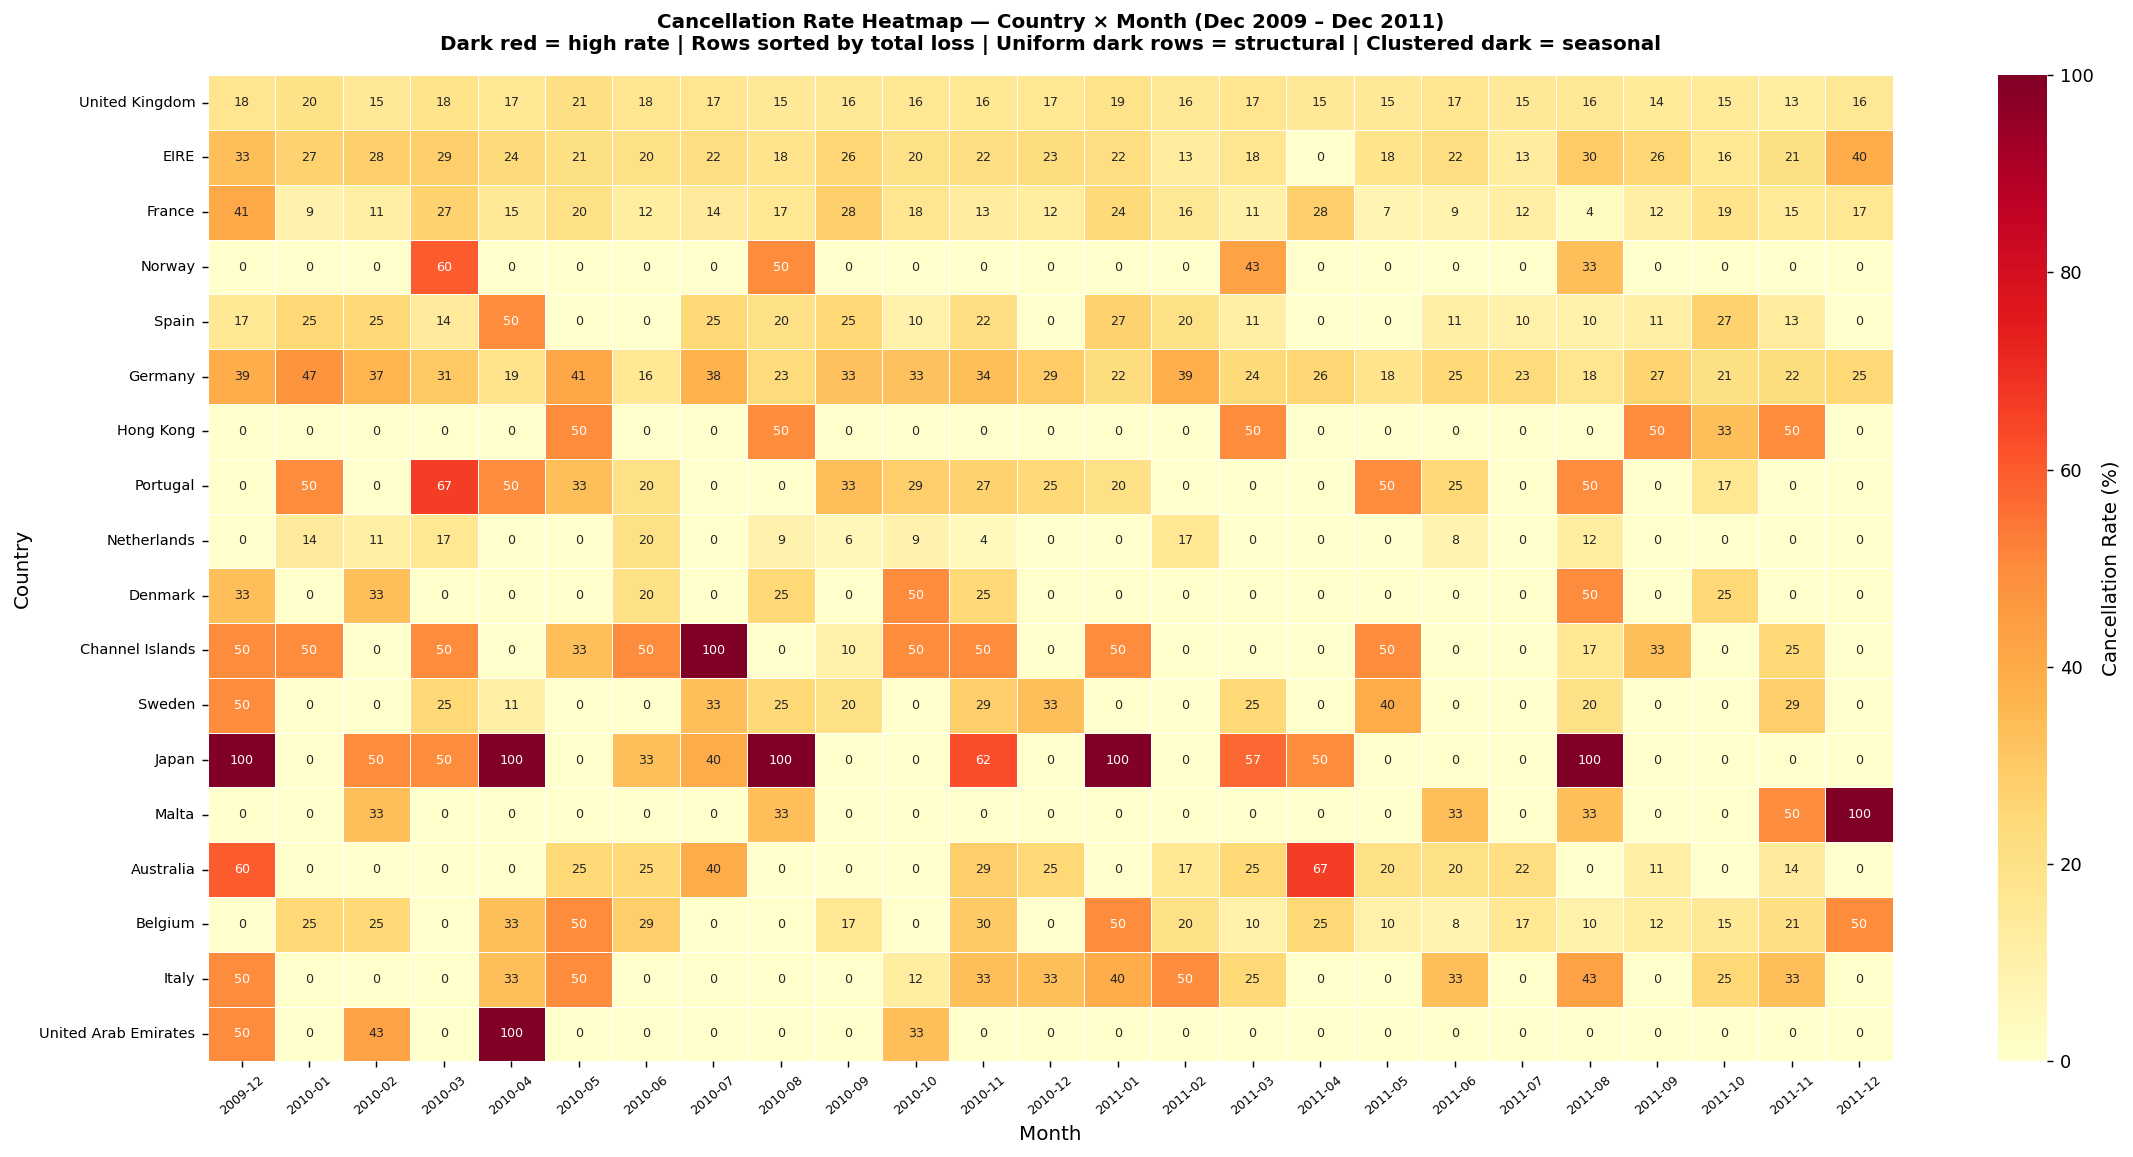


📌 How to Read This Heatmap:
   UNIFORM dark row (dark across all months) = STRUCTURAL problem
   → Country is consistently failing regardless of season
   → Examples: Germany, Japan, Malta

   CLUSTERED dark cells (dark only in Q4/Q1) = SEASONAL problem
   → Country struggles specifically during holiday periods

   LIGHT row = well-functioning market (Netherlands, Czech Republic with low volume)

   This directly addresses Professor Eman's feedback:
   geographic + temporal findings are connected, not siloed.


In [21]:
# Countries with at least 5 cancelled invoices total
valid_countries = geo[
    (geo['Cancelled_Invoices'] >= 5) &
    (geo.index != 'Unspecified')
].index.tolist()

heat_total  = (df[df['Country'].isin(valid_countries)]
               .groupby(['Country','Month'])['Invoice']
               .nunique().reset_index(name='Total'))
heat_cancel = (df[(df['Cancelled']) & (df['Country'].isin(valid_countries))]
               .groupby(['Country','Month'])['Invoice']
               .nunique().reset_index(name='Cancelled'))

heat_merged = heat_total.merge(heat_cancel, on=['Country','Month'], how='left').fillna(0)
heat_merged['Rate'] = (heat_merged['Cancelled'] / heat_merged['Total'] * 100).round(1)
heat_pivot  = heat_merged.pivot(index='Country', columns='Month', values='Rate').fillna(0)
heat_pivot.columns = [str(c) for c in heat_pivot.columns]

# Sort rows by total loss
order = [c for c in geo.sort_values('Loss_GBP', ascending=False).index
         if c in heat_pivot.index]
heat_pivot = heat_pivot.reindex(order).head(18)

fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(heat_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Cancellation Rate (%)'},
            ax=ax, annot_kws={'size': 7})

ax.set_title('Cancellation Rate Heatmap — Country × Month (Dec 2009 – Dec 2011)\n'
             'Dark red = high rate | Rows sorted by total loss | '
             'Uniform dark rows = structural | Clustered dark = seasonal',
             pad=14, fontsize=11)
ax.set_xlabel('Month')
ax.set_ylabel('Country')
ax.tick_params(axis='x', rotation=40, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('chart10_heatmap.png', bbox_inches='tight')
plt.show()

print()
print('📌 How to Read This Heatmap:')
print('   UNIFORM dark row (dark across all months) = STRUCTURAL problem')
print('   → Country is consistently failing regardless of season')
print('   → Examples: Germany, Japan, Malta')
print()
print('   CLUSTERED dark cells (dark only in Q4/Q1) = SEASONAL problem')
print('   → Country struggles specifically during holiday periods')
print()
print('   LIGHT row = well-functioning market (Netherlands, Czech Republic with low volume)')
print()
print('   This directly addresses Professor Eman\'s feedback:')
print('   geographic + temporal findings are connected, not siloed.')

---
## 5. Summary of All Findings & Team Handoffs

In [22]:
print('=' * 75)
print('  GEOGRAPHIC & TEMPORAL ANALYSIS — FINAL INSIGHT SUMMARY')
print('=' * 75)

# ── Key metrics ─────────────────────────────────────────────
uk_loss  = geo.loc['United Kingdom', 'Loss_GBP']
total_loss = geo['Loss_GBP'].sum()
uk_share = uk_loss / total_loss * 100
uk_rate  = geo.loc['United Kingdom', 'Cancel_Rate_Pct']

# ────────────────────────────────────────────────────────────
print('\n✅ Q1: Are return rates significantly higher in specific countries?')
print('   YES — and they fall into TWO distinct types of risk:\n')

print('   1) UK — VOLUME RISK')
print(f'      • £{uk_loss:,.0f} loss ({uk_share:.1f}% of total)')
print(f'      • Cancellation rate: {uk_rate:.1f}% (moderate, not highest)')
print('      → Risk driven by SCALE, not abnormal behaviour\n')

print('   2) STRUCTURAL RISK COUNTRIES')
for c in ['Germany','Japan','Malta']:
    if c in geo.index:
        print(f'      • {c}: {geo.loc[c,"Cancel_Rate_Pct"]:.1f}% rate')

print('\n   → These countries show persistently high rates across BOTH years')
print('   → This is NOT random or seasonal — it is a structural issue')


# ────────────────────────────────────────────────────────────
print('\n✅ Q2: Are cancellations seasonal?')
print('   YES for volume — NO for behaviour\n')

mean_rate = monthly['Cancel_Rate_Pct'].mean()

print(f'   • 2-year average cancellation rate: {mean_rate:.1f}% (stable year-round)')
print('   • Q4 shows higher LOSSES, not higher RATES')

print('\n   → Customers are NOT more likely to cancel in holidays')
print('   → The business processes MORE orders, increasing total cancellations')


# ────────────────────────────────────────────────────────────
print('\n🔷 CORE BUSINESS INSIGHT:')
print('   Cancellation behaviour is stable and predictable.')
print('   Risk is driven by three independent forces:\n')

print('   1. Volume concentration (UK)')
print('   2. Structural country issues (Germany, Japan, Malta)')
print('   3. Product-specific bulk cancellation events')


# ────────────────────────────────────────────────────────────
print('\n' + '=' * 75)
print('  TEAM HANDOFF RECOMMENDATIONS (CRITICAL)')
print('=' * 75)


# ── RENATO (Customer Analysis) ──────────────────────────────
print('\n👉 TO RENATO (Customer Analysis):')
print('   Focus on WHO drives cancellations\n')

print('   1. Identify repeat vs one-time cancellers')
print('      → Are cancellations concentrated in a small group of customers?')

print('\n   2. Investigate spike months (Sep 2010, Dec 2010, Jan 2011)')
print('      → Are large cancellations linked to the SAME customers?')
print('      → Possible B2B / bulk buyer behaviour')

print('\n   3. Compare high-frequency vs low-frequency customers')
print('      → Do frequent buyers cancel more?')

print('\n   🎯 GOAL:')
print('      Determine whether cancellations are CUSTOMER-DRIVEN')
print('      or broadly distributed across all users')


# ── OKAH (Product Analysis) ─────────────────────────────────
print('\n👉 TO OKAH (Product Analysis):')
print('   Focus on WHAT is being returned and WHY\n')

print('   1. High-risk countries (Germany, Japan, Malta)')
print('      → Which SKUs are driving high cancellation rates?')
print('      → Check for product-market mismatch')

print('\n   2. Spike products (very important)')
print('      → Large losses driven by specific SKUs, not all products')
print('      → Likely bulk orders or quality issues')

print('\n   3. Compare high-return vs low-return products')
print('      → Price range, category, description quality')

print('\n   🎯 GOAL:')
print('      Identify predictable PRODUCT risk factors')


# ────────────────────────────────────────────────────────────
print('\n' + '=' * 75)
print('FINAL BUSINESS CONCLUSION:')
print('Returns are NOT random and NOT seasonal behaviour-driven.')
print('They are predictable outcomes driven by geography, product issues, and customer patterns.')
print('This means return risk can be actively managed and reduced.')
print('=' * 75)

  GEOGRAPHIC & TEMPORAL ANALYSIS — FINAL INSIGHT SUMMARY

✅ Q1: Are return rates significantly higher in specific countries?
   YES — and they fall into TWO distinct types of risk:

   1) UK — VOLUME RISK
      • £1,104,222 loss (85.3% of total)
      • Cancellation rate: 16.4% (moderate, not highest)
      → Risk driven by SCALE, not abnormal behaviour

   2) STRUCTURAL RISK COUNTRIES
      • Germany: 27.9% rate
      • Japan: 40.0% rate
      • Malta: 40.0% rate

   → These countries show persistently high rates across BOTH years
   → This is NOT random or seasonal — it is a structural issue

✅ Q2: Are cancellations seasonal?
   YES for volume — NO for behaviour

   • 2-year average cancellation rate: 16.9% (stable year-round)
   • Q4 shows higher LOSSES, not higher RATES

   → Customers are NOT more likely to cancel in holidays
   → The business processes MORE orders, increasing total cancellations

🔷 CORE BUSINESS INSIGHT:
   Cancellation behaviour is stable and predictable.
   Ris